In [1]:
import hvplot.xarray
import numpy as np
import xarray as xr

In [4]:
def load_merged_argo_dataset_and_tumo_obs(time_smoothing, lat_bounds = None):
    ds_argo_merged = xr.open_dataset(f'../rapid-geostrophic-reconstruction/data/ds_argo_{time_smoothing}.nc')
    t_umo_obs = xr.open_dataset(f'../rapid-geostrophic-reconstruction/data/t_umo_obs_2000ref.nc')

    t_umo_obs = t_umo_obs.resample(time = time_smoothing).mean()

    ds_argo_merged = ds_argo_merged.sel(time = t_umo_obs.time.data)#, method = 'nearest')
    ds_argo_merged = ds_argo_merged.isel(z = slice(None, None, -1))

    if lat_bounds is not None:
        ds_argo_merged = ds_argo_merged.where((ds_argo_merged.lat >= lat_bounds[0]) & (ds_argo_merged.lat <= lat_bounds[1]))

    return ds_argo_merged, t_umo_obs


def load_merged_argo_dataset_and_tumo(time_smoothing, lat_bounds = None, suffix = None):
    ds_argo_merged = xr.open_dataset(f'../rapid-geostrophic-reconstruction/data/ds_argo_{time_smoothing}_viking{suffix}_12A.nc')
    t_umo_obs = xr.open_dataset(f'../rapid-geostrophic-reconstruction/data/t_umo_sim_miss{suffix}_2000ref_12A.nc')
    t_umo_obs['time'] = t_umo_obs.time.dt.floor('D')
    t_umo_obs = t_umo_obs.resample(time = time_smoothing).mean()

    ds_argo_merged = ds_argo_merged.sel(time = t_umo_obs.time.data, method = 'nearest')
    ds_argo_merged = ds_argo_merged.isel(z = slice(None, None, -1))

    if lat_bounds is not None:
        ds_argo_merged = ds_argo_merged.where((ds_argo_merged.lat >= lat_bounds[0]) & (ds_argo_merged.lat <= lat_bounds[1]))

    return ds_argo_merged, t_umo_obs

In [5]:
# Load the argo_dataset and the ground truth dataset

import xarray as xr
import pandas as pd
time_smoothing = '90D'

lat_bounds = (25, 27)


# ds_argo_merged, t_umo_obs = load_merged_argo_dataset_and_tumo(time_smoothing)#, lat_bounds = lat_bounds)

def load_merged_argo_dataset_and_tumo_cycles(suffixe, time_smoothing):
    ds_argo_merged = None
    t_umo_obs = None
    assert len(suffixe) == 2, 'Longer? Think on the t_delta '

    for suffix in suffixe:
        ds_argo_merged_cycle, t_umo_obs_cycle = load_merged_argo_dataset_and_tumo(time_smoothing, suffix= suffix)

        if ds_argo_merged is None:
            ds_argo_merged = ds_argo_merged_cycle
            t_umo_obs = t_umo_obs_cycle
        else:
            t_delta = ds_argo_merged.time.max() - ds_argo_merged_cycle.time.min() + pd.Timedelta(time_smoothing)
            ds_argo_merged_cycle['time'] = ds_argo_merged_cycle['time'] + t_delta 
            t_umo_obs_cycle['time'] = t_umo_obs_cycle['time'] + t_delta
            ds_argo_merged_cycle['time_1d'] = ds_argo_merged_cycle['time_1d'] + t_delta

            ds_argo_merged = xr.concat([ds_argo_merged, ds_argo_merged_cycle], dim = 'time')
            t_umo_obs = xr.concat([t_umo_obs, t_umo_obs_cycle], dim = 'time')

    return ds_argo_merged, t_umo_obs, t_delta

suffixe = ['_70None', '_2nd_NoneNone']
ds_argo_merged, t_umo_obs, t_delta = load_merged_argo_dataset_and_tumo_cycles(suffixe, time_smoothing)

/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(


In [6]:
t_umo_obs.dv_dz_times_X.hvplot()

:Curve   [time]   (dv_dz_times_X)

## Single Profile Processing

We will load the ds_argo_merged dataset as thre base where each prfoile in the ten day window is present.
THen we will create 4 embedding one for each of the moorings and each profile is assigned by distance to those emebeddings. 
Each profile will create based on the currtent state and its rho values a delta that will be added to the embedding.

In [11]:
ds_pos_1st = xr.open_dataset('../rapid-geostrophic-reconstruction/data/ds_pos_sim_miss_70None_2000ref_12A.nc')
ds_pos_1st = ds_pos_1st.resample(time = time_smoothing).mean()
ds_pos_2nd = xr.open_dataset('../rapid-geostrophic-reconstruction/data/ds_pos_sim_miss_2nd_NoneNone_2000ref_12A.nc')
ds_pos_2nd = ds_pos_2nd.resample(time = time_smoothing).mean()

ds_pos_2nd['time'] = ds_pos_2nd['time'] + t_delta

ds_pos_sim = xr.concat([ds_pos_1st, ds_pos_2nd], dim = 'time')

ds_pos_sim

<xarray.Dataset>
Dimensions:          (z: 242, pos: 4, time: 485)
Coordinates:
  * z                (z) float64 -0.0 -20.0 -40.0 ... -4.8e+03 -4.82e+03
  * pos              (pos) object 'west' 'marwest' 'mareast' 'east'
    lat              (pos) float64 26.52 24.52 24.52 26.99
    lon              (pos) float64 -76.74 -50.57 -41.21 -16.23
    pressure         (z) float64 0.0 20.0 40.0 ... 4.78e+03 4.8e+03 4.82e+03
    name             (pos) object 'west' 'marwest' 'mareast' 'east'
  * time             (time) datetime64[ns] 1970-04-01 1970-06-30 ... 2089-07-05
Data variables:
    temperature      (time, z, pos) float64 nan nan nan ... 1.487 1.784 1.768
    salinity         (time, z, pos) float64 nan nan nan ... 34.84 34.87 34.87
    missing_indices  (time, pos) float64 2.433 4.0 125.0 ... 3.078 125.0 4.789
    ct               (time, z, pos) float64 nan nan nan ... 1.487 1.784 1.767
    rho              (time, z, pos) float64 nan nan nan ... 1.049e+03 1.049e+03
Attributes:
    standard_name:       sea_water_potential_temperature
    long_name:           temperature
    units:               degC
    online_operation:    average
    interval_operation:  300 s
    interval_write:      1 d
    cell_methods:        time: mean (interval: 300 s) time_counter: mean

In [8]:
dv_dz_obs_1st = xr.open_dataset('../rapid-geostrophic-reconstruction/data/dv_dz_sim_miss_fillup_70None_2000ref_12A.nc')
dv_dz_obs_1st = dv_dz_obs_1st.resample(time = time_smoothing).mean()
dv_dz_obs_2nd = xr.open_dataset('../rapid-geostrophic-reconstruction/data/dv_dz_sim_miss_fillup_2nd_NoneNone_2000ref_12A.nc')
dv_dz_obs_2nd = dv_dz_obs_2nd.resample(time = time_smoothing).mean()

dv_dz_obs_2nd['time'] = dv_dz_obs_2nd['time'] + t_delta

dv_dz_obs = xr.concat([dv_dz_obs_1st, dv_dz_obs_2nd], dim = 'time')

dv_dz_obs.mean('time').dv_dz_times_X#.interpolate_na('z')

<xarray.DataArray 'dv_dz_times_X' (z: 242)>
array([-4.24316399e+00, -4.23026593e+00, -4.21734927e+00, -4.20441405e+00,
       -4.19146028e+00, -4.17848797e+00, -4.16549716e+00, -4.15248785e+00,
       -4.13946008e+00, -4.12641386e+00, -4.10556001e+00, -4.07618672e+00,
       -4.04697732e+00, -4.01793205e+00, -3.98905115e+00, -3.96033485e+00,
       -3.93178340e+00, -3.90339702e+00, -3.87517596e+00, -3.84712045e+00,
       -3.81923072e+00, -3.79150701e+00, -3.75093845e+00, -3.62592562e+00,
       -3.50181463e+00, -3.37860610e+00, -3.25630067e+00, -3.13489897e+00,
       -3.01440160e+00, -2.89480919e+00, -2.77612236e+00, -2.65834172e+00,
       -2.54146787e+00, -2.42550143e+00, -2.31044299e+00, -2.26395122e+00,
       -2.22951143e+00, -2.19535673e+00, -2.16148706e+00, -2.12790235e+00,
       -2.09460255e+00, -2.06158759e+00, -2.02885740e+00, -1.99641192e+00,
       -1.96425107e+00, -1.93237479e+00, -1.90078301e+00, -1.81450608e+00,
       -1.69902484e+00, -1.58436075e+00, -1.47051395e+00, -1.35748461e+00,
       -1.24527289e+00, -1.13387893e+00, -1.02330288e+00, -9.13544881e-01,
       -7.75347553e-01, -9.55901636e-02, -1.35648852e-01, -2.41910899e-01,
       -4.05047262e-01, -5.67328035e-01, -7.28753479e-01, -8.89323860e-01,
       -1.04903945e+00, -1.20790051e+00, -1.36590733e+00, -1.52306018e+00,
       -1.67935935e+00, -1.83480513e+00, -1.98939781e+00, -2.03174115e+00,
       -1.97846134e+00, -1.92558921e+00, -1.87312412e+00, -1.82106545e+00,
       -1.76941258e+00, -1.71816489e+00, -1.66732174e+00, -1.61688250e+00,
...
        2.69364892e+00,  2.86731437e+00,  3.03974590e+00,  3.21095350e+00,
        4.09594877e+00,  5.58668106e+00,  7.08808531e+00,  8.60017334e+00,
        1.01229572e+01,  1.16564493e+01,  1.32006621e+01,  1.47556084e+01,
        1.63213012e+01,  1.70706913e+01,  1.77152352e+01,  1.83605606e+01,
        1.90066776e+01,  1.96535964e+01,  2.03013270e+01,  2.09498795e+01,
        2.15992641e+01,  2.16362406e+01,  2.15627427e+01,  2.14903288e+01,
        2.14189915e+01,  2.13487235e+01,  2.12795176e+01,  2.12113665e+01,
        2.03527985e+01,  1.85565740e+01,  1.67409281e+01,  1.49058929e+01,
        1.30514997e+01,  1.11777788e+01,  9.28475967e+00,  5.76393674e+00,
        1.59513796e+00, -2.71529678e+00, -7.16627915e+00, -1.17567524e+01,
       -1.64856904e+01, -2.11127913e+01, -2.60489472e+01, -3.14143101e+01,
       -3.72035224e+01, -4.34114273e+01, -4.89884384e+01, -5.34613582e+01,
       -5.84840668e+01, -6.40492091e+01, -7.01497042e+01, -7.67610450e+01,
       -8.38826829e+01, -9.15150604e+01, -9.96520085e+01, -1.05383754e+02,
       -1.09566751e+02, -1.13898145e+02, -1.18085071e+02, -1.19905313e+02,
       -1.21720648e+02, -1.23502545e+02, -1.24997522e+02, -1.26438931e+02,
       -1.29068588e+02, -1.32688494e+02, -1.37705178e+02, -1.44889372e+02,
       -1.54494785e+02, -1.66071593e+02, -1.80578705e+02, -1.96372226e+02,
       -2.12148502e+02, -2.28024433e+02, -2.43706180e+02, -2.59387928e+02,
       -2.75069675e+02, -2.90751422e+02])
Coordinates:
  * z        (z) float64 -4.82e+03 -4.8e+03 -4.78e+03 ... -40.0 -20.0 -0.0

In [9]:
from copy import deepcopy

In [10]:
ds_argo_merged_10days, t_umo_10days, t_delta = load_merged_argo_dataset_and_tumo_cycles(['_70None', '_2nd_NoneNone'], '90D')

compartments = [
    ['west_p', -76.74, -70, 'west'],
    ['mar_west_p', -60, -47, 'east'],
    ['mar_east_p', -47, -40, 'west'],
    ['east_p', -30, -13.5, 'east']
]

# VIKING contains more detailed information in the upper layers as the Argo dataset
# Argo only measures each 20 meters while VIKING has measurments at 0, 3, 9, 12 ... meters

boundaries = np.arange(-10000, 1, 20) + 10
depth_grouped = ds_argo_merged_10days.groupby_bins('z', boundaries).mean()
depth_grouped = depth_grouped.where(ds_argo_merged_10days.z.groupby_bins('z', boundaries).count() > 0)


ds_argo_merged_10days = depth_grouped.assign_coords(z_bins = ('z_bins', np.arange(-10000, 1, 20)[1:])).rename({'z_bins': 'z'}).sel(z = ds_argo_merged_10days.z, method = 'nearest').assign_coords(z = ds_argo_merged_10days.z).transpose('time', 'pos', 'z')

# We only take the first 2000 meters depth
ds_argo_merged_10days = ds_argo_merged_10days.where(ds_argo_merged_10days.z > -2000, drop = True)

ds_argo_merged_10days = ds_argo_merged_10days.where(ds_argo_merged_10days.salinity > 0)
# ds_argo_merged_10days = ds_argo_merged_10days.where((ds_argo_merged_10days.z <= -1500) | (ds_argo_merged_10days.z > -100) , drop = True)
# ds_argo_merged_10days = ds_argo_merged_10days.where((ds_argo_merged_10days.z <= -1500) , drop = True)

ds_argo_merged_10days = ds_argo_merged_10days.sortby('z')

/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(


In [13]:
load_std = True

# Prepare a dataset by 1) splitting the data, 2) scaling the input data 
train_slice_pos = 'start'

train_ratio = .6
val_ratio = .15


# t_umo_10days = t_umo_10days.sel(time = slice(None, '2020-01-01'))
# ds_argo_merged_10days = ds_argo_merged_10days.sel(time = slice(None, '2020-01-01'))


# indices = np.arange(t_umo_10days.time.shape[0])
# np.random.shuffle(indices)


    


# if train_slice_pos == 'start':
#     train_indices = indices[:int(train_ratio * indices.shape[0])]
#     val_indices = indices[int(train_ratio * indices.shape[0]):int((train_ratio + val_ratio) * indices.shape[0])]
#     test_indices = indices[int((train_ratio + val_ratio) * indices.shape[0]):]
# elif train_slice_pos == 'end':
#     train_indices = indices[-int(train_ratio * indices.shape[0]):]
#     val_indices = indices[-int((train_ratio + val_ratio) * indices.shape[0]): -int(train_ratio * indices.shape[0])]
#     test_indices = indices[:-int((train_ratio + val_ratio) * indices.shape[0])]

test_indices = t_umo_10days.assign_coords(ti = ('time', np.arange(len(t_umo_10days.time)))).sel(time = slice('2005-01-01', '2025-01-01')).ti.values
# test_indices = t_umo_10days.assign_coords(ti = ('time', np.arange(len(t_umo_10days.time)))).sel(time = slice('2055-01-01', None)).ti.values
valid_indices_1 =  t_umo_10days.assign_coords(ti = ('time', np.arange(len(t_umo_10days.time)))).sel(time = slice('1995-01-01', '2005-01-01')).ti.values
valid_indices_2 =  t_umo_10days.assign_coords(ti = ('time', np.arange(len(t_umo_10days.time)))).sel(time = slice('2025-01-01','2035-01-01')).ti.values
val_indices = np.concatenate([valid_indices_1, valid_indices_2])
# val_indices =  t_umo_10days.assign_coords(ti = ('time', np.arange(len(t_umo_10days.time)))).sel(time = slice('2035-01-01', '2055-01-01')).ti.values


test_indices = t_umo_10days.assign_coords(ti = ('time', np.arange(len(t_umo_10days.time)))).sel(time = slice('2010-01-01', '2023-08-01')).ti.values
valid_indices_1 =  t_umo_10days.assign_coords(ti = ('time', np.arange(len(t_umo_10days.time)))).sel(time = slice('2000-01-01', '2010-01-01')).ti.values
valid_indices_2 =  t_umo_10days.assign_coords(ti = ('time', np.arange(len(t_umo_10days.time)))).sel(time = slice('2025-01-01','2035-01-01')).ti.values
val_indices = np.concatenate([valid_indices_1, valid_indices_2])





train_mask = ~np.isin(np.arange(t_umo_10days.time.shape[0]), np.concatenate((val_indices, test_indices)))
train_indices = np.arange(t_umo_10days.time.shape[0])[train_mask]




rho_mean = ds_argo_merged_10days.where(ds_argo_merged_10days.profile_mask).mean(['time', 'pos']).rho
temperature_mean = ds_argo_merged_10days.where(ds_argo_merged_10days.profile_mask).mean(['time', 'pos']).temperature
salinity_mean = ds_argo_merged_10days.where(ds_argo_merged_10days.profile_mask).mean(['time', 'pos']).salinity

if load_std:
    temperature_std = xr.open_dataset('../rapid-geostrophic-reconstruction/data/train_temperature_std_argo.nc').temperature
    salinity_std = xr.open_dataset('../rapid-geostrophic-reconstruction/data/train_salinity_std_argo.nc').salinity
    rho_std = xr.open_dataset('../rapid-geostrophic-reconstruction/data/train_rho_std_argo.nc').rho
    std_transport = xr.open_dataset('../rapid-geostrophic-reconstruction/data/train_transport_std_argo.nc').dv_dz_times_X
else:
    rho_std = ds_argo_merged_10days.where(ds_argo_merged_10days.profile_mask).isel(time = train_indices).std(['time', 'pos']).rho
    temperature_std = ds_argo_merged_10days.where(ds_argo_merged_10days.profile_mask).isel(time = train_indices).std(['time', 'pos']).temperature
    salinity_std = ds_argo_merged_10days.where(ds_argo_merged_10days.profile_mask).isel(time = train_indices).std(['time', 'pos']).salinity
    std_transport = t_umo_10days.isel(time = train_indices).std('time').dv_dz_times_X




def standardize_rho(ds_pos, rho_mean=None, rho_std=None):
    ds_pos = deepcopy(ds_pos)
    ds_pos["rho"] = (ds_pos["rho"] - rho_mean) / rho_std
    return ds_pos

def standardize_temperature(ds_pos, temperature_mean=None, temperature_std=None):
    ds_pos = deepcopy(ds_pos)
    ds_pos["temperature"] = (ds_pos["temperature"] - temperature_mean) / temperature_std
    return ds_pos

def standardize_salinity(ds_pos, salinity_mean=None, salinity_std=None):
    ds_pos = deepcopy(ds_pos)
    ds_pos["salinity"] = (ds_pos["salinity"] - salinity_mean) / salinity_std
    return ds_pos


ds_argo_merged_10days_std = standardize_rho(
    ds_argo_merged_10days,
    rho_mean=rho_mean, 
    rho_std=rho_std,
)

ds_argo_merged_10days_std = standardize_temperature(
    ds_argo_merged_10days_std,
    temperature_mean=temperature_mean,
    temperature_std=temperature_std,
)

ds_argo_merged_10days_std = standardize_salinity(
    ds_argo_merged_10days_std,
    salinity_mean=salinity_mean,
    salinity_std=salinity_std,
)

ds_argo_merged_10days_std = ds_argo_merged_10days_std.fillna(0)

nn_feature_ds = xr.concat(
    [
        ds_argo_merged_10days_std.rho, 
        # ds_argo_merged_10days_std.temperature, 
        # ds_argo_merged_10days_std.salinity
        ], dim = 'feature'
).stack(nn_feature = ['feature', 'z'])
train_X_scaled = nn_feature_ds.isel(time = train_indices).values
val_X_scaled = nn_feature_ds.isel(time = val_indices).values
test_X_scaled = nn_feature_ds.isel(time = test_indices).values


train_X_mask = ds_argo_merged_10days.isel(time = train_indices).profile_mask.fillna(0).astype(bool).values
val_X_mask = ds_argo_merged_10days.isel(time = val_indices).profile_mask.fillna(0).astype(bool).values
test_X_mask = ds_argo_merged_10days.isel(time = test_indices).profile_mask.fillna(0).astype(bool).values

train_X_lon = ds_argo_merged_10days.isel(time = train_indices).lon.values
val_X_lon = ds_argo_merged_10days.isel(time = val_indices).lon.values
test_X_lon = ds_argo_merged_10days.isel(time = test_indices).lon.values

offset_days = (
    (
        ds_argo_merged_10days.time_1d -
        ds_argo_merged_10days.time
    )
    .fillna(0).dt.days 
)

train_X_days = offset_days.isel(time = train_indices).values
val_X_days = offset_days.isel(time = val_indices).values
test_X_days = offset_days.isel(time = test_indices).values

train_y = t_umo_10days.isel(time = train_indices).dv_dz_times_X
val_y = t_umo_10days.isel(time = val_indices).dv_dz_times_X
test_y = t_umo_10days.isel(time = test_indices).dv_dz_times_X

train_y_prev = t_umo_10days.isel(
    time = xr.DataArray(train_indices.reshape(-1, 1) - (np.arange(3) + 1).reshape(1,-1))
).dv_dz_times_X.values
val_y_prev = t_umo_10days.isel(
    time = xr.DataArray(val_indices.reshape(-1, 1) - (np.arange(3) + 1).reshape(1,-1))
).dv_dz_times_X.values
test_y_prev = t_umo_10days.isel(
    time = xr.DataArray(test_indices.reshape(-1, 1) - (np.arange(3) + 1).reshape(1,-1))
).dv_dz_times_X.values

# train_y_prev = dv_dz_obs.where(dv_dz_obs.z > -2000, drop = True).isel(
#     time = xr.DataArray(train_indices.reshape(-1, 1) - (np.arange(2) + 1).reshape(1,-1))
# ).dv_dz_times_X.values.reshape(train_indices.shape[0], -1)
# val_y_prev = dv_dz_obs.where(dv_dz_obs.z > -2000, drop = True).isel(
#     time = xr.DataArray(val_indices.reshape(-1, 1) - (np.arange(2) + 1).reshape(1,-1))
# ).dv_dz_times_X.values.reshape(val_indices.shape[0], -1)
# test_y_prev = dv_dz_obs.where(dv_dz_obs.z > -2000, drop = True).isel(
#     time = xr.DataArray(test_indices.reshape(-1, 1) - (np.arange(2) + 1).reshape(1,-1))
# ).dv_dz_times_X.values.reshape(test_indices.shape[0], -1)


mean_transport  = train_y.mean('time')

train_y_scaled = (train_y - mean_transport) / std_transport
val_y_scaled = (val_y - mean_transport) / std_transport
test_y_scaled = (test_y - mean_transport) / std_transport

train_y_prev_scaled = (train_y_prev - mean_transport.values) / std_transport.values
val_y_prev_scaled = (val_y_prev - mean_transport.values) / std_transport.values
test_y_prev_scaled = (test_y_prev - mean_transport.values) / std_transport.values

train_y_scaled = train_y_scaled.fillna(0).values
val_y_scaled = val_y_scaled.fillna(0).values
test_y_scaled = test_y_scaled.fillna(0).values

# train_y_prev_scaled = train_y_prev_scaled.fillna(0).values
# val_y_prev_scaled = val_y_prev_scaled.fillna(0).values
# test_y_prev_scaled = test_y_prev_scaled.fillna(0).values

# dv_dz_obs = xr.open_dataset('../rapid-geostrophic-reconstruction/data/dv_dz_sim_miss_70None.nc')
# dv_dz_obs = dv_dz_obs.resample(time = time_smoothing).mean()
dv_dz_moorings = dv_dz_obs.sel(time = ds_argo_merged_10days.time, method='nearest').where(dv_dz_obs.z <= -2000, drop = True)

mean_dv_dz_moorings = dv_dz_moorings.isel(time = train_indices).mean(['time']).dv_dz_times_X
std_dv_dz_moorings = dv_dz_moorings.isel(time = train_indices).std(['time']).dv_dz_times_X

train_dv_dz_moorings_scaled = ((dv_dz_moorings.isel(time = train_indices).dv_dz_times_X - mean_dv_dz_moorings) / std_dv_dz_moorings).fillna(0).values
val_dv_dz_moorings_scaled = ((dv_dz_moorings.isel(time = val_indices).dv_dz_times_X - mean_dv_dz_moorings) / std_dv_dz_moorings).fillna(0).values
test_dv_dz_moorings_scaled = ((dv_dz_moorings.isel(time = test_indices).dv_dz_times_X - mean_dv_dz_moorings) / std_dv_dz_moorings).fillna(0).values


# missing_indices = ds_pos_sim



# ds_argo_merged_10days


In [24]:
scaled_mis_positions = ds_pos_sim.sel(time = ds_argo_merged_10days.time, method='nearest').missing_indices / 10


train_missing_indices = scaled_mis_positions.isel(time = train_indices).values
val_missing_indices = scaled_mis_positions.isel(time = val_indices).values
test_missing_indices = scaled_mis_positions.isel(time = test_indices).values

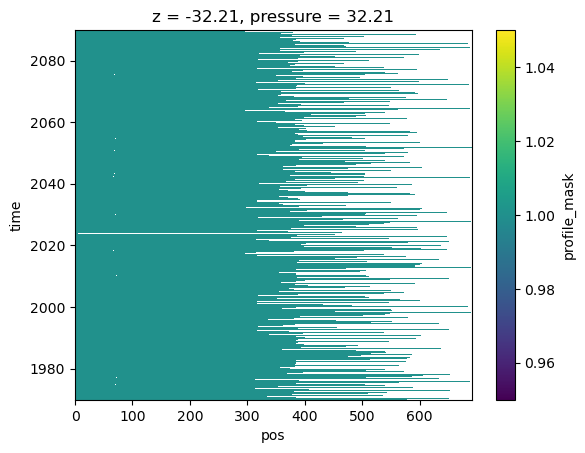

In [396]:
ds_argo_merged_10days.profile_mask.isel(z = -5).plot()

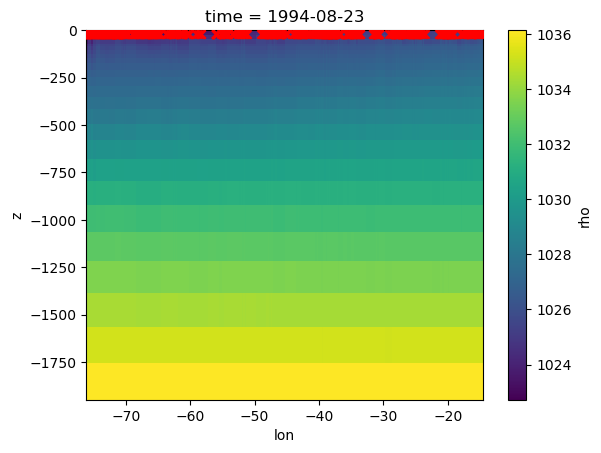

In [397]:
import matplotlib.pyplot as plt
fig = plt.figure()
ax = fig.add_subplot(1,1,1)

ds_argo_merged_10days.isel(time = 100).rho.sortby('lon').dropna('pos').plot(x = 'lon', y = 'z', ax = ax)

ax.scatter(ds_argo_merged_10days.isel(time = 100).lon, np.ones_like(ds_argo_merged_10days.isel(time = 0).lon) * -20, c = 'r', zorder = 10, marker='x')

In [25]:
from xarray import open_dataset
def load_masks(nest, model):

    if str.startswith(model, 'VIKING20X.L46-KFS003'):
        # All the mask for the long runs VIKING20X.L46-KFS003-2nd, ... are placed in the original experiment
        model = 'VIKING20X.L46-KFS003' 
    
    nest_part = '1_' if nest else ''
    
    mask_mesh = open_dataset(
        f'/gxfs_work/geomar/smomw355/model_data/ocean-only/{model}/nemo/suppl/{nest_part}mesh_mask.nc',
        decode_cf=False,
        chunks={'y': 100, 'x':100, 'z': -1},
    )

    if model == 'VIKING20X.L46-KFS003' and not nest:
        nest_part = 'ori_'

    mask_glo = open_dataset(
        f'/gxfs_work/geomar/smomw355/model_data/ocean-only/{model}/nemo/suppl/{nest_part}new_maskglo.nc',
        decode_cf=False,
        chunks={'Y':100, 'X':100, 'z': -1}
    )

    mask_mesh = mask_mesh.squeeze()
    mask_glo = mask_glo.rename({'X':'x', 'Y':'y'}).squeeze() # Rename coordinates to have the same name as the data file
    
    return mask_mesh, mask_glo

mask_mesh, mask_glo = load_masks(True, 'VIKING20X.L46-KFS003')

In [399]:
ts = 110
mask_mesh.tmask.isel(y = np.abs(mask_mesh.nav_lat.mean('x') - 26.5).argmin().values[()])


lon_bins = mask_mesh.nav_lon.isel(y = np.abs(mask_mesh.nav_lat.mean('x') - 26.5).argmin().values[()]).values

indices = np.abs(ds_argo_merged_10days.isel(time = ts).dropna('pos').lon.values.reshape(-1,1) - lon_bins.reshape(1, -1)).argmin(axis = -1)

nan_image = np.full(shape = (lon_bins.shape[0], 46), fill_value=np.nan)
nan_image[indices, :29] = ds_argo_merged_10days.isel(time = ts).dropna('pos').rho.values



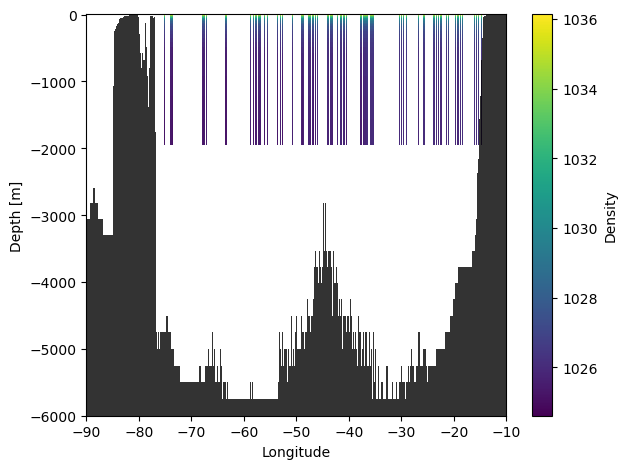

In [400]:
fig = plt.figure()
ax = fig.add_subplot(1,1,1)
bottom = mask_mesh.tmask.isel(y = np.abs(mask_mesh.nav_lat.mean('x') - 26.5).argmin().values[()]).values.astype(np.float32)

bottom[bottom == 1] = np.NaN

rho = ax.pcolormesh(lon_bins, ds_argo_merged.z, nan_image.T, cmap = 'viridis')
ax.pcolormesh(lon_bins, ds_argo_merged.z, bottom, cmap = 'grey', alpha=.8)


plt.colorbar(rho, ax = ax, label = 'Density')
ax.set_xlabel('Longitude')
ax.set_ylabel('Depth [m]')
ax.set_xlim(-90, -10)

# ax.set_title(f'{np.datetime_as_string(ds_argo_merged_10days.time[ts].values[()], unit="D")} - {np.datetime_as_string(ds_argo_merged_10days.time[ts+1].values[()], unit="D")}')

fig.tight_layout()
plt.savefig('../rapid-geostrophic-reconstruction/argo_profiles.png', dpi = 300)

In [401]:
ds_argo_merged_10days.where((ds_argo_merged_10days.profile_mask)).isel(time = train_indices).rho.isel(z = -2).hvplot.kde()

:NdOverlay   [Variable]
   :Distribution   [value]   (Density)

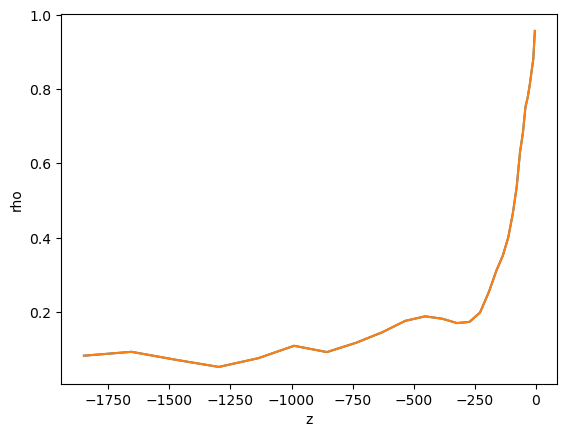

In [402]:
xr.open_dataset('../rapid-geostrophic-reconstruction/data/train_rho_std_argo.nc').rho.plot()
rho_std.plot()

In [29]:
from torch.utils.data import DataLoader, TensorDataset, Dataset
class ProfileDataset(Dataset):
    def __init__(self, X, y, y_prev, mask, lon, dv_dz, days, compartments, missing_indices):
        self.X = X
        self.y = y
        self.y_prev = y_prev
        self.mask = mask
        self.lon = lon
        self.days = days
        self.compartment = compartments 
        self.dv_dz = dv_dz
        self.missing_indices = missing_indices

        self.len_compartments = len(compartments)

        self.X_per_compartment = []
        self.lon_per_compartment = []
        self.dv_dz_per_compartment = []
        self.days_per_compartment = []
        self.missing_indices_per_compartment = []

        self.min_longitude = min([comp[1] for comp in compartments])
        self.max_longitude = max([comp[2] for comp in compartments])



        self.lon_scaled = (self.lon - self.min_longitude) / (self.max_longitude - self.min_longitude)

        self.days_scaled = self.days / (pd.Timedelta(time_smoothing).days / 2)
        
        for i in range(len(self)):
            mask = self.mask[i]


            compartment_X_per_sample = []
            compartment_lon_per_sample = []
            compartment_days_per_sample = []

            for j in range(self.len_compartments):

                # get all profile indices that are in the compartment and in the mask 
                profile_indices = np.where((self.lon[i] > self.compartment[j][1]) & (self.lon[i] < self.compartment[j][2]) & mask.any(axis = -1))[0]

                if len(profile_indices) < 1:
                    compartment_X_per_sample.append(np.empty(0))
                    compartment_lon_per_sample.append(np.empty(0))
                    compartment_days_per_sample.append(np.empty(0))
                    continue

                lon_compartments = self.lon_scaled[i][profile_indices]
                sorted_indices_longitude = lon_compartments.argsort()


                # If I have the sequence -5, -15, 5 the argsort will return [1, 0, 2]
                # As we want to have those profiles as last that are closes to the mooring due to the vanishing gradient 
                # For West moorings the smallest value has to be the last one
                if self.compartment[j][3] == 'west':
                    sorted_indices_longitude = sorted_indices_longitude[::-1]
                
                profile_indices = profile_indices[sorted_indices_longitude]

                compartment_X_per_sample.append(self.X[i][ profile_indices])
                compartment_lon_per_sample.append(self.lon_scaled[i][profile_indices])
                compartment_days_per_sample.append(self.days_scaled[i][profile_indices])
            

            self.X_per_compartment.append(compartment_X_per_sample)
            self.lon_per_compartment.append(compartment_lon_per_sample)
            self.dv_dz_per_compartment.append(self.dv_dz[i])
            self.missing_indices_per_compartment.append(self.missing_indices[i])
            self.days_per_compartment.append(compartment_days_per_sample)


    def __len__(self):
        return self.X.shape[0] 

    def __getitem__(self, idx):
        return self.X_per_compartment[idx], self.y[idx], self.y_prev[idx], self.lon_per_compartment[idx], self.dv_dz_per_compartment[idx], self.days_per_compartment[idx], self.missing_indices_per_compartment[idx]

In [30]:
import torch
train_dataset = ProfileDataset(train_X_scaled, train_y, train_y_prev_scaled, train_X_mask, train_X_lon, train_dv_dz_moorings_scaled, train_X_days, compartments, train_missing_indices)
val_dataset = ProfileDataset(val_X_scaled, val_y, val_y_prev_scaled, val_X_mask, val_X_lon, val_dv_dz_moorings_scaled, val_X_days, compartments, val_missing_indices)
test_dataset = ProfileDataset(test_X_scaled, test_y, test_y_prev_scaled, test_X_mask, test_X_lon, test_dv_dz_moorings_scaled, test_X_days, compartments, test_missing_indices)
    

def merge_profiles(data):
    """
        X: is a list and each entry is a list of compartments in which the profiles are stored with variable length
    """
    X, y, y_prev, lon, dv_dz, days, missing_indices = zip(*data)
    X = [[torch.tensor(x_compartment).float() for x_compartment in x_sample] for x_sample in X]
    y = torch.tensor(np.array(y)).float()
    y_prev = torch.tensor(np.array(y_prev)).float()
    lon = [[torch.tensor(lon_compartment).float() for lon_compartment in lon_sample] for lon_sample in lon]
    dv_dz = [torch.tensor(dv_dz_sample).float() for dv_dz_sample in dv_dz]
    missing_indices = [torch.tensor(missing_indices_sample).float() for missing_indices_sample in missing_indices]
    days = [[torch.tensor(days_compartment).float() for days_compartment in day_sample] for day_sample in days]

    

    return X, y, y_prev, lon, dv_dz, days,missing_indices

dl = DataLoader(train_dataset, batch_size=16, shuffle=True, collate_fn=merge_profiles, num_workers=4)
val_dl = DataLoader(val_dataset, batch_size=32, shuffle=False, collate_fn=merge_profiles, num_workers=4)
test_dl = DataLoader(test_dataset, batch_size=32, shuffle=False, collate_fn=merge_profiles, num_workers=4)


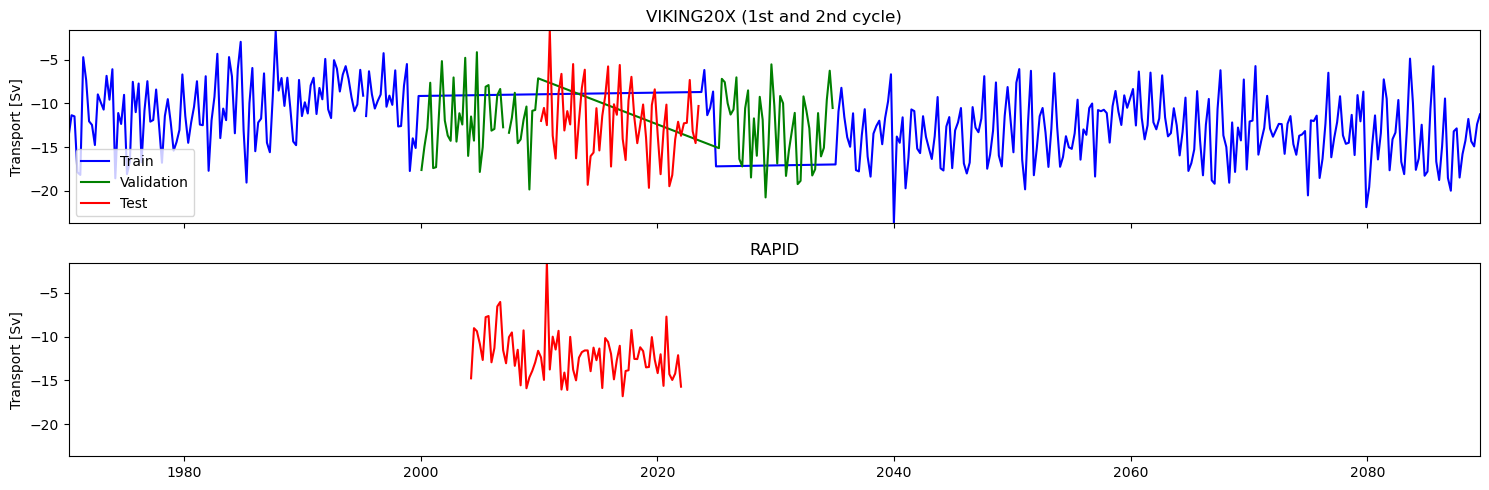

In [31]:
import matplotlib.pyplot as plt

ds_argo_merged_obs, t_umo_obs_obs = load_merged_argo_dataset_and_tumo_obs(time_smoothing)#, lat_bounds = lat_bounds)


fig = plt.figure(figsize=(15,5))
ax = fig.add_subplot(2,1,1)

train1 = t_umo_10days.isel(time = train_indices[train_indices <= 101]).dv_dz_times_X
ax.plot(train1.time, train1.values, c = 'b', label = 'Train')
train2 = t_umo_10days.isel(time = train_indices[train_indices > 101]).dv_dz_times_X
ax.plot(train2.time, train2.values, c = 'b')


val1 = t_umo_10days.isel(time = val_indices[val_indices < 150]).dv_dz_times_X
val2 = t_umo_10days.isel(time = val_indices[val_indices > 150]).dv_dz_times_X

ax.plot(val1.time, val1.values, c = 'g', label ='Validation')
ax.plot(val2.time, val2.values, c = 'g')

test = t_umo_10days.isel(time = test_indices).dv_dz_times_X
ax.plot(test.time, test.values, c = 'r', label = 'Test')

ax.set_xlim(t_umo_10days.time.min().data, t_umo_10days.time.max().data)
ax.set_ylim(t_umo_10days.dv_dz_times_X.min().data, t_umo_10days.dv_dz_times_X.max().data)
ax.set_xticklabels([])
ax.set_title('VIKING20X (1st and 2nd cycle)')
ax.set_ylabel('Transport [Sv]')
plt.legend()
ax = fig.add_subplot(2,1,2)
ax.set_xlim(t_umo_10days.time.min().data, t_umo_10days.time.max().data)
ax.set_ylim(t_umo_10days.dv_dz_times_X.min().data, t_umo_10days.dv_dz_times_X.max().data)

ax.set_title('RAPID')
ax.plot(t_umo_obs_obs.dv_dz_times_X.time, t_umo_obs_obs.dv_dz_times_X.values, c = 'r')
ax.set_ylabel('Transport [Sv]')
fig.tight_layout()
fig.savefig('../rapid-geostrophic-reconstruction/train_val_test_split.png')

## Models

### SUSTeR LIB

In [33]:
#Original SUSTeR
import torch.nn as nn
import torch.nn.functional as F
import torch.nn.init as init
import math

class Align(nn.Module):
    def __init__(self, c_in, c_out):
        super(Align, self).__init__()
        self.c_in = c_in
        self.c_out = c_out
        self.align_conv = nn.Conv2d(
            in_channels=c_in, out_channels=c_out, kernel_size=(1, 1))

    def forward(self, x):
        if self.c_in > self.c_out:
            x = self.align_conv(x)
        elif self.c_in < self.c_out:
            batch_size, _, timestep, n_vertex = x.shape
            x = torch.cat([x, torch.zeros(
                [batch_size, self.c_out - self.c_in, timestep, n_vertex]).to(x)], dim=1)
        else:
            x = x

        return x


class CausalConv1d(nn.Conv1d):
    def __init__(self, in_channels, out_channels, kernel_size, stride=1, enable_padding=False, dilation=1, groups=1, bias=True):
        if enable_padding == True:
            self.__padding = (kernel_size - 1) * dilation
        else:
            self.__padding = 0
        super(CausalConv1d, self).__init__(in_channels, out_channels, kernel_size=kernel_size,
                                           stride=stride, padding=self.__padding, dilation=dilation, groups=groups, bias=bias)

    def forward(self, input):
        result = super(CausalConv1d, self).forward(input)
        if self.__padding != 0:
            return result[:, :, : -self.__padding]

        return result


class CausalConv2d(nn.Conv2d):
    def __init__(self, in_channels, out_channels, kernel_size, stride=1, enable_padding=False, dilation=1, groups=1, bias=True):
        kernel_size = nn.modules.utils._pair(kernel_size)
        stride = nn.modules.utils._pair(stride)
        dilation = nn.modules.utils._pair(dilation)
        if enable_padding == True:
            self.__padding = [int((kernel_size[i] - 1) * dilation[i])
                              for i in range(len(kernel_size))]
        else:
            self.__padding = 0
        self.left_padding = nn.modules.utils._pair(self.__padding)
        super(CausalConv2d, self).__init__(in_channels, out_channels, kernel_size,
                                           stride=stride, padding=0, dilation=dilation, groups=groups, bias=bias)

    def forward(self, input):
        if self.__padding != 0:
            input = F.pad(
                input, (self.left_padding[1], 0, self.left_padding[0], 0))
        result = super(CausalConv2d, self).forward(input)

        return result


class TemporalConvLayer(nn.Module):

    # Temporal Convolution Layer (GLU)
    #
    #        |--------------------------------| * Residual Connection *
    #        |                                |
    #        |    |--->--- CasualConv2d ----- + -------|
    # -------|----|                                   ⊙ ------>
    #             |--->--- CasualConv2d --- Sigmoid ---|
    #

    # param x: tensor, [bs, c_in, ts, n_vertex]

    def __init__(self, Kt, c_in, c_out, n_vertex, act_func):
        super(TemporalConvLayer, self).__init__()
        self.Kt = Kt
        self.c_in = c_in
        self.c_out = c_out
        self.n_vertex = n_vertex
        self.align = Align(c_in, c_out)
        if act_func == 'glu' or act_func == 'gtu':
            self.causal_conv = CausalConv2d(
                in_channels=c_in, out_channels=2 * c_out, kernel_size=(Kt, 1), enable_padding=False, dilation=1)
        else:
            self.causal_conv = CausalConv2d(in_channels=c_in, out_channels=c_out, kernel_size=(
                Kt, 1), enable_padding=False, dilation=1)
        self.act_func = act_func
        self.sigmoid = nn.Sigmoid()
        self.tanh = nn.Tanh()
        self.relu = nn.ReLU()
        self.leaky_relu = nn.LeakyReLU()
        self.silu = nn.SiLU()

    def forward(self, x):
        x_in = self.align(x)[:, :, self.Kt - 1:, :]
        x_causal_conv = self.causal_conv(x)

        if self.act_func == 'glu' or self.act_func == 'gtu':
            x_p = x_causal_conv[:, : self.c_out, :, :]
            x_q = x_causal_conv[:, -self.c_out:, :, :]

            if self.act_func == 'glu':
                # GLU was first purposed in
                # *Language Modeling with Gated Convolutional Networks*.
                # URL: https://arxiv.org/abs/1612.08083
                # Input tensor X is split by a certain dimension into tensor X_a and X_b.
                # In the original paper, GLU is defined as Linear(X_a) ⊙ Sigmoid(Linear(X_b)).
                # However, in PyTorch, GLU is defined as X_a ⊙ Sigmoid(X_b).
                # URL: https://pytorch.org/docs/master/nn.functional.html#torch.nn.functional.glu
                # Because in original paper, the representation of GLU and GTU is ambiguous.
                # So, it is arguable which one version is correct.

                # (x_p + x_in) ⊙ Sigmoid(x_q)
                x = torch.mul((x_p + x_in), self.sigmoid(x_q))

            else:
                # Tanh(x_p + x_in) ⊙ Sigmoid(x_q)
                x = torch.mul(self.tanh(x_p + x_in), self.sigmoid(x_q))

        elif self.act_func == 'relu':
            x = self.relu(x_causal_conv + x_in)

        elif self.act_func == 'leaky_relu':
            x = self.leaky_relu(x_causal_conv + x_in)

        elif self.act_func == 'silu':
            x = self.silu(x_causal_conv + x_in)

        else:
            raise NotImplementedError(
                f'ERROR: The activation function {self.act_func} is not implemented.')

        return x


class ChebGraphConv(nn.Module):
    def __init__(self, c_in, c_out, Ks, bias):
        super(ChebGraphConv, self).__init__()
        self.c_in = c_in
        self.c_out = c_out
        self.Ks = Ks
        self.weight = nn.Parameter(torch.FloatTensor(Ks, c_in, c_out))
        if bias:
            self.bias = nn.Parameter(torch.FloatTensor(c_out))
        else:
            self.register_parameter('bias', None)
        self.reset_parameters()

    def reset_parameters(self):
        init.kaiming_uniform_(self.weight, a=math.sqrt(5))
        if self.bias is not None:
            fan_in, _ = init._calculate_fan_in_and_fan_out(self.weight)
            bound = 1 / math.sqrt(fan_in) if fan_in > 0 else 0
            init.uniform_(self.bias, -bound, bound)

    def forward(self, x, gso):
        #bs, c_in, ts, n_vertex = x.shape
        x = torch.permute(x, (0, 2, 3, 1))

        gso = gso.to(x.device)

        if self.Ks - 1 < 0:
            raise ValueError(
                f'ERROR: the graph convolution kernel size Ks has to be a positive integer, but received {self.Ks}.')
        elif self.Ks - 1 == 0:
            x_0 = x
            x_list = [x_0]
        elif self.Ks - 1 == 1:
            x_0 = x
            x_1 = torch.einsum('bhi,btij->bthj', gso, x)
            x_list = [x_0, x_1]
        elif self.Ks - 1 >= 2:
            x_0 = x
            x_1 = torch.einsum('bhi,btij->bthj', gso, x)
            x_list = [x_0, x_1]
            for k in range(2, self.Ks):
                x_list.append(torch.einsum('bhi,btij->bthj', 2 *
                              gso, x_list[k - 1]) - x_list[k - 2])

        x = torch.stack(x_list, dim=2)

        cheb_graph_conv = torch.einsum('btkhi,kij->bthj', x, self.weight)

        if self.bias is not None:
            cheb_graph_conv = torch.add(cheb_graph_conv, self.bias)
        else:
            cheb_graph_conv = cheb_graph_conv

        return cheb_graph_conv


class GraphConv(nn.Module):
    def __init__(self, c_in, c_out, bias):
        super(GraphConv, self).__init__()
        self.c_in = c_in
        self.c_out = c_out
        self.weight = nn.Parameter(torch.FloatTensor(c_in, c_out))
        if bias:
            self.bias = nn.Parameter(torch.FloatTensor(c_out))
        else:
            self.register_parameter('bias', None)
        self.reset_parameters()

    def reset_parameters(self):
        init.kaiming_uniform_(self.weight, a=math.sqrt(5))
        if self.bias is not None:
            fan_in, _ = init._calculate_fan_in_and_fan_out(self.weight)
            bound = 1 / math.sqrt(fan_in) if fan_in > 0 else 0
            init.uniform_(self.bias, -bound, bound)

    def forward(self, x, gso):
        #bs, c_in, ts, n_vertex = x.shape
        x = torch.permute(x, (0, 2, 3, 1))

        first_mul = torch.einsum('hi,btij->bthj', gso, x)
        second_mul = torch.einsum('bthi,ij->bthj', first_mul, self.weight)

        if self.bias is not None:
            graph_conv = torch.add(second_mul, self.bias)
        else:
            graph_conv = second_mul

        return graph_conv


class GraphConvLayer(nn.Module):
    def __init__(self, graph_conv_type, c_in, c_out, Ks, bias):
        super(GraphConvLayer, self).__init__()
        self.graph_conv_type = graph_conv_type
        self.c_in = c_in
        self.c_out = c_out
        self.align = Align(c_in, c_out)
        self.Ks = Ks
        if self.graph_conv_type == 'cheb_graph_conv':
            self.cheb_graph_conv = ChebGraphConv(c_out, c_out, Ks, bias)
        elif self.graph_conv_type == 'graph_conv':
            self.graph_conv = GraphConv(c_out, c_out, bias)

    def forward(self, x, gso):
        x_gc_in = self.align(x)
        if self.graph_conv_type == 'cheb_graph_conv':
            x_gc = self.cheb_graph_conv(x_gc_in, gso)
        elif self.graph_conv_type == 'graph_conv':
            x_gc = self.graph_conv(x_gc_in, gso)
        x_gc = x_gc.permute(0, 3, 1, 2)
        x_gc_out = torch.add(x_gc, x_gc_in)

        return x_gc_out


class STConvBlock(nn.Module):
    # STConv Block contains 'TGTND' structure
    # T: Gated Temporal Convolution Layer (GLU or GTU)
    # G: Graph Convolution Layer (ChebGraphConv or GraphConv)
    # T: Gated Temporal Convolution Layer (GLU or GTU)
    # N: Layer Normolization
    # D: Dropout

    def __init__(self, Kt, Ks, n_vertex, last_block_channel, channels, act_func, graph_conv_type, bias, droprate):
        super(STConvBlock, self).__init__()
        self.tmp_conv1 = TemporalConvLayer(
            Kt, last_block_channel, channels[0], n_vertex, act_func)
        self.graph_conv = GraphConvLayer(
            graph_conv_type, channels[0], channels[1], Ks, bias)
        self.tmp_conv2 = TemporalConvLayer(
            Kt, channels[1], channels[2], n_vertex, act_func)
        self.tc2_ln = nn.LayerNorm([n_vertex, channels[2]])
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(p=droprate)

    def forward(self, x, gso):
        x = self.tmp_conv1(x)
        x = self.graph_conv(x, gso)
        x = self.relu(x)
        x = self.tmp_conv2(x)
        x = self.tc2_ln(x.permute(0, 2, 3, 1)).permute(0, 3, 1, 2)
        x = self.dropout(x)

        return x, gso


class OutputBlock(nn.Module):
    # Output block contains 'TNFF' structure
    # T: Gated Temporal Convolution Layer (GLU or GTU)
    # N: Layer Normolization
    # F: Fully-Connected Layer
    # F: Fully-Connected Layer

    def __init__(self, Ko, last_block_channel, channels, end_channel, n_vertex, act_func, bias, droprate):
        super(OutputBlock, self).__init__()
        self.tmp_conv1 = TemporalConvLayer(
            Ko, last_block_channel, channels[0], n_vertex, act_func)
        self.fc1 = nn.Linear(
            in_features=channels[0], out_features=channels[1], bias=bias)
        self.fc2 = nn.Linear(
            in_features=channels[1], out_features=end_channel, bias=bias)
        self.tc1_ln = nn.LayerNorm([n_vertex, channels[0]])
        self.relu = nn.ReLU()
        self.leaky_relu = nn.LeakyReLU()
        self.silu = nn.SiLU()
        self.dropout = nn.Dropout(p=droprate)

    def forward(self, x):
        x = self.tmp_conv1(x)
        x = self.tc1_ln(x.permute(0, 2, 3, 1))
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x).permute(0, 3, 1, 2)

        return x


class ContextAwareMeanState(nn.Module):

    def __init__(self, n_proxy, n_embedding, n_context) -> None:
        super().__init__()

        self.n_proxy = n_proxy
        self.n_embedding = n_embedding

        self.fc1 = nn.Linear(n_context, n_embedding)
        self.fc2 = nn.Linear(n_embedding, n_proxy * n_embedding)


    def forward(self, context):

        global_embed = self.fc1(context)
        global_embed = F.relu(global_embed)

        Xbar = self.fc2(global_embed)

        return Xbar.reshape(-1, self.n_proxy, self.n_embedding)
    

class Embedding(nn.Module):

    def __init__(self, embed_dim, obs_dim, n_proxy) -> None:
        super().__init__()
        self.fc1_1 = nn.Linear(obs_dim + embed_dim * n_proxy, embed_dim)
        self.fc1_2 = nn.Linear(embed_dim , embed_dim)

        self.fc2_1 = nn.Linear(2, n_proxy)
        self.fc2_2 = nn.Linear(n_proxy, n_proxy)

        self.fc3_1 = nn.Linear(embed_dim, embed_dim)

        self.embed_dim = embed_dim
        self.n_proxy = n_proxy

    def forward(self, obs, v):
        
        ## Concat O and X for the embedding vector. 
        input = torch.concat((obs, v.reshape( -1).unsqueeze(dim = 0).expand(obs.shape[0], -1)), dim = -1)
        
        ## Create from the O and X the piece of information that should be incorporated into the network.
        x_emebdding = self.fc1_1(input)
        x_emebdding = F.relu(x_emebdding)
        x_emebdding = self.fc1_2(x_emebdding)
        x_emebdding = F.relu(x_emebdding)


        ## Use the position of the observations to find the best matching hidden node.
        positions = obs[..., :2]
        x_proxies = self.fc2_1(positions)
        x_proxies = F.relu(x_proxies)
        x_proxies = self.fc2_2(x_proxies)

        proxy_density = F.softmax(x_proxies, dim = -1) 

        ## Sample a single graph node from the created distributions and add the information to those nodes.
        sampled_proxy_index = torch.multinomial(proxy_density.reshape(-1, self.n_proxy), 1)
        mask = proxy_density#F.one_hot(sampled_proxy_index, num_classes = self.n_proxy).float().reshape(proxy_density.shape)
       
        obs_mask = torch.any(obs != 0, dim = -1).unsqueeze(dim=-1).expand(-1, self.n_proxy)
        mask = torch.mul(obs_mask, mask)

        new_information = self.fc3_1(x_emebdding)
        dotV_obs = torch.matmul(mask.unsqueeze(dim = -1), new_information.unsqueeze(dim = -2))

        return dotV_obs, mask

class SimpleOutput(nn.Module):

    def __init__(self, n_proxy, embed_dim, n_target) -> None:
        super().__init__()

        self.fc1 = nn.Linear(n_proxy * embed_dim, 256)
        self.fc2 = nn.Linear(256, 128)

        self.map = nn.Linear(128, n_target)

    def forward(self, VF, TP):

        x = self.fc1(VF)
        x = F.relu(x)
        x = self.fc2(x)
        x = F.relu(x)
        y = self.map(x)

        return y

class LocationBasedOutputv2(nn.Module):

    def __init__(self, n_proxy, embed_dim, targets) -> None:
        super().__init__()

        self.reduce = nn.Sequential(
            nn.Linear(n_proxy * embed_dim, 256),
            nn.ReLU(),
            nn.Linear(256,embed_dim)
        )

        self.proxy_porportion = nn.Sequential(
            nn.Linear(4 + embed_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, n_proxy)
        )
        self.fc3 = nn.Linear(embed_dim, embed_dim)
        self.map = nn.Linear(embed_dim, 1)

        self.n_proxy = n_proxy
        self.embed_dim = embed_dim


    def forward(self, VF, target_positions):

        global_state = self.reduce(VF).unsqueeze(dim = 1)
        pos_with_glob_state = torch.concat((global_state.expand(-1, target_positions.shape[0], -1), target_positions.unsqueeze(dim = 0).expand(VF.shape[0], -1, -1)), dim=-1)
        p_proxy = F.softmax(F.relu(self.proxy_porportion(pos_with_glob_state)), dim = -1)


        VF = VF.reshape(VF.shape[0], self.n_proxy, self.embed_dim)
        accumulated_information = torch.einsum('bsp,bpe->bse', p_proxy, VF)

        x = self.fc3(accumulated_information)
        x = F.relu(x)
        y = self.map(x) 

        return y

class mySequential(nn.Sequential):
    def forward(self, *input):
        for module in self._modules.values():
            input = module(*input)
        return input


class STGCNChebGraphConv(nn.Module):
    """
    Paper: Spatio-Temporal Graph Convolutional Networks: A Deep Learning Framework for Trafﬁc Forecasting
    Official Code: https://github.com/VeritasYin/STGCN_IJCAI-18 (tensorflow)
    Ref Code: https://github.com/hazdzz/STGCN
    Note:  
        https://github.com/hazdzz/STGCN/issues/9
    Link: https://arxiv.org/abs/1709.04875
    """

    # STGCNChebGraphConv contains 'TGTND TGTND TNFF' structure
    # ChebGraphConv is the graph convolution from ChebyNet.
    # Using the Chebyshev polynomials of the first kind as a graph filter.

    # T: Gated Temporal Convolution Layer (GLU or GTU)
    # G: Graph Convolution Layer (ChebGraphConv)
    # T: Gated Temporal Convolution Layer (GLU or GTU)
    # N: Layer Normolization
    # D: Dropout

    # T: Gated Temporal Convolution Layer (GLU or GTU)
    # G: Graph Convolution Layer (ChebGraphConv)
    # T: Gated Temporal Convolution Layer (GLU or GTU)
    # N: Layer Normolization
    # D: Dropout

    # T: Gated Temporal Convolution Layer (GLU or GTU)
    # N: Layer Normalization
    # F: Fully-Connected Layer
    # F: Fully-Connected Layer

    def __init__(self, Kt, Ks, blocks, T, n_vertex, act_func, graph_conv_type, bias, droprate):
        super(STGCNChebGraphConv, self).__init__()
        modules = []
        for l in range(len(blocks) - 3):
            modules.append(STConvBlock(
                Kt, Ks, n_vertex, blocks[l][-1], blocks[l+1], act_func, graph_conv_type, bias, droprate))
        self.st_blocks = mySequential(*modules)
        Ko = T - (len(blocks) - 3) * 2 * (Kt - 1)
        self.Ko = Ko
        assert Ko != 0, "Ko = 0."
        self.output = OutputBlock(
            Ko, blocks[-3][-1], blocks[-2], blocks[-1][0], n_vertex, act_func, bias, droprate)

    def forward(self, history_data: torch.Tensor, gso: torch.Tensor, **kwargs) -> torch.Tensor:
        """feedforward function of STGCN.

        Args:
            history_data (torch.Tensor): historical data with shape [B, L, N, C]

        Returns:
            torch.Tensor: prediction with shape [B, L, N, C]
        """
        x = history_data.permute(0, 3, 1, 2).contiguous()

        x, _ = self.st_blocks(x, gso)
        x = self.output(x)

        # x = x.transpose(2, 3)
        x = x.permute(0, 2, 3, 1)
        return x
    
    
    



class SUSTeR(nn.Module):


    def __init__(self, n_proxy, embed_dim, n_channels, target, context_meanstate = False, norm_adj = False, factor = 1) -> None:

        super().__init__()

        self.norm_adj = norm_adj
        self.n_proxy = n_proxy
        self.embed_dim = embed_dim

        if context_meanstate:
            self.mean_state = ContextAwareMeanState(n_proxy, embed_dim, 2)
        else:
            self.mean_state = nn.Parameter(torch.randn(size = (self.n_proxy, self.embed_dim)) * .5, requires_grad= True)

      
        self.embedding = Embedding(embed_dim, n_channels, n_proxy)
        self.factor = factor
        if factor is not None:
            self.stgcn = STGCNChebGraphConv(3, 3, [[embed_dim], [64//factor, 16//factor, 64//factor], [64//factor, 16//factor, 64//factor], [128//factor, 128//factor], [embed_dim]], 12, n_proxy, 'glu', 'cheb_graph_conv', True, .5)


        if np.isscalar(target):
            self.output = SimpleOutput(n_proxy, embed_dim, target)
        else:
            self.output = LocationBasedOutputv2(n_proxy, embed_dim, target)

        
    def forward(self, x):

        batch_embeddings = []
        
        for batch_i in range(len(x)):
            compartment_embeddings = []
            observations = x[batch_i]
            nT, nS, nC = observations.shape

         

            # 1. Get the mean state from the context information.
            if isinstance(self.mean_state, nn.Module):
                raise NotImplementedError("Not implemented yet")
                mean_state = self.mean_state(target_positions[:, 0, :2])
            else:
                mean_state = self.mean_state
                # mean_state = torch.tile(mean_state, dims = (nB, 1, 1))
            

            # 2. Create an graph for each of the provided timesteps
            delta_proxies = [mean_state] 
            p_densities = []

            for timestep in range(nT):
                
                obs_t = observations[timestep] # [sensors, channels]

                # 2.1 Embed each observation into an embedding for each of the proxies
                embeddings, proxy_density = self.embedding(obs_t, delta_proxies[-1].detach()) # [sensors, proxy * embed]

                p_densities.append(proxy_density)

                # 2.2 Sum over all the emebeddings which count to real observations
                mask_observations = torch.any(obs_t != 0, dim = -1).unsqueeze(dim=-1).unsqueeze(dim=-1).expand(-1, self.n_proxy, self.embed_dim) # [ sensors, 1, 1]
                embeddings_mul = torch.mul(embeddings , mask_observations.int()) # Set all the non existing observation to zero

                if mask_observations[..., 0,0].sum() == 0.0: 
                    delta_proxy_embedding = torch.zeros(size= (self.n_proxy, self.embed_dim), device = observations.device)
                else:
                    delta_proxy_embedding = torch.sum(embeddings_mul, dim = 0)
                delta_proxies.append(delta_proxy_embedding)


            delta_proxies = torch.stack(delta_proxies, dim = 0)
            graphs = torch.cumsum(delta_proxies, dim = 0)

            # 3. Calculate the laplace matrix for the graph sequence from the last hidden state.
            if not self.norm_adj:        
                adj_mx = torch.softmax(torch.relu(torch.einsum('pe,le->pl', graphs[-1], graphs[-1])), dim = -1)
            else:
                norm_graph = graphs[ -1]/ (torch.norm(graphs[-1], p = 2, dim = -1, keepdim= True) + 1e-6)
                adj_mx = torch.softmax(torch.relu(torch.einsum('pe,le->pl',norm_graph, norm_graph)), dim = -1)

            # 4. Use the wrapped STGNN for the forward propagation of information through the hidden spatio temporal graph.
            if self.factor is not None:
                full_state = self.stgcn(graphs[1:].unsqueeze(0), adj_mx.unsqueeze(0)).squeeze(0) # [1, p, e]
            else:
                full_state = torch.mean(graphs[1:], dim = 1)


            batch_embeddings.append(full_state)
            # 5. Project the full state onto the spatial domain
            # out = self.output(full_state.reshape( -1), target_positions)

        # return out.reshape(nB, 1, -1, 1), self.output(mean_state.reshape(nB, -1), target_positions).reshape(nB, 1, -1, 1)
        return torch.stack(batch_embeddings, dim = 0)

### SUSTER orig

In [34]:
class ProfileModelSUSTeRorig(nn.Module):
    def __init__(self, n_features, n_compartments, n_embedding, n_dvdz_features, z_scale, device, profile_embedder = None, nT = 12):
        super(ProfileModelSUSTeRorig, self).__init__()
        self.n_compartments = n_compartments #* n_compartments
        self.n_features = n_features
        self.n_dvdz_features = n_dvdz_features
        self.n_embedding = n_embedding
        self.fc1 = nn.Linear(n_embedding * self.n_compartments +n_dvdz_features  , 256)
        self.bn1 = nn.BatchNorm1d(num_features=256)
        self.fc2 = nn.Linear(256,128)
        self.dropout1 = nn.Dropout(p=.25)
        self.fc3 = nn.Linear(128,64)
        self.dropout2 = nn.Dropout(p=.33)
        self.fc4 = nn.Linear(64,64)
        self.bn2 = nn.BatchNorm1d(num_features=64)
        self.dropout3 = nn.Dropout(p=.2)
        self.fc5 = nn.Linear(64,32)
        self.fc6 = nn.Linear(32,242)

        self.profile_embedder = profile_embedder

        self.transformer = PredictionToTransportModel(z_scale, torch.tensor(dv_dz_obs.dv_dz_times_X.mean('time').fillna(0).values).to(device), torch.tensor(dv_dz_obs.dv_dz_times_X.std('time').fillna(1).values).to(device))

        self.device = device

        self.nT = nT

        self.suster = SUSTeR(n_proxy = n_compartments, embed_dim = n_embedding, n_channels = n_features + 2, target = 1, context_meanstate = False, norm_adj = False, factor = 1)

    def forward(self, x, lon, dv_dz, days):

        
        batch_embeddings = []
        for batch_i in range(len(x)):
            compartment_embeddings = []
            x_batch = x[batch_i]

            x_batch = torch.cat(x_batch, dim = 0) # (n_profiles, n_features)

            lon_batch = torch.cat(lon[batch_i], dim = 0) # (n_profiles)

            days_batch = torch.cat(days[batch_i], dim = 0) # (n_profiles)  


            input_to_suster = torch.cat((
                lon_batch.reshape(-1,1), 
                days_batch.reshape(-1,1),
                x_batch, 
            ), dim = -1) 


            bounds = torch.linspace(-1, 1, self.nT + 1)
            temporal_input = []
            for b_min, b_max in zip(bounds[:-1], bounds[1:]):
                
                t_mask = (days_batch >= b_min) & (days_batch < b_max)
                temporal_input.append(input_to_suster[t_mask])

            max_len = max([len(t) for t in temporal_input])

            temporal_input = [torch.cat((t, torch.zeros(max_len - len(t), input_to_suster.shape[1]).to(self.device)), dim = 0) for t in temporal_input]

            temporal_input = torch.stack(temporal_input, dim = 0) # [t,s,f]
                

            full_state = self.suster(temporal_input.unsqueeze(dim = 0)) # [1, 1, p, e]

            embedding_all_profiles = full_state.squeeze_(dim = 0).squeeze_(dim = 0).flatten()

            embedding_all_profiles = torch.concat([embedding_all_profiles, torch.zeros_like(dv_dz[batch_i])], dim = 0)
            batch_embeddings.append(embedding_all_profiles)
        embedding_all_profiles = torch.stack(batch_embeddings)
        assert not torch.isnan(embedding_all_profiles).any(), 'NaN in embedding_all_profiles'
        x = torch.relu(self.fc1(embedding_all_profiles))
        # x = self.bn1(x)
        # x = self.dropout1(x)
        x = torch.relu(self.fc2(x))
        # x = self.dropout2(x)
        x = torch.relu(self.fc3(x))
        # x = self.dropout3(x)
        x = torch.relu(self.fc4(x))
        # x = self.bn2(x)
        x = torch.relu(self.fc5(x))
        x = self.fc6(x)
        x = x.squeeze(dim = -1)

        return self.transformer(x)

In [35]:
from torch import nn

class PredictionToTransportModel(nn.Module):

    def __init__(self, z_scale, mean_per_z, std_per_z ):
        super(PredictionToTransportModel, self).__init__()
        self.mean_per_z = torch.tensor(mean_per_z).float()
        self.std_per_z = torch.tensor(std_per_z).float()
        self.bottom_index = np.argmin(np.abs(z_scale - -4800).values)
        self.amoc_index = np.argmin(np.abs(z_scale - -1000).values)

    def forward(self, x):
        x = x * self.std_per_z + self.mean_per_z

        dv_dz_prediction = x


        velocity_aggregation = torch.cumsum(dv_dz_prediction.flip(-1), -1) * 20
        velocity_at_level_of_no_motion = velocity_aggregation[:, [self.bottom_index]]
        return (
            -((torch.cumsum(dv_dz_prediction.flip(-1), -1) * 20) -
            (torch.cumsum(dv_dz_prediction.flip(-1), -1) * 20).flip(-1)[:, [self.bottom_index]]).cumsum(-1) * 20 / 1e6
        ).flip(-1)[:, self.amoc_index]


class CompartmentModel(nn.Module):

    def __init__(self, n_features, n_embedding):
        super(CompartmentModel, self).__init__()
        self.n_features = n_features
        self.n_embedding = n_embedding
        self.fc1 = nn.Linear(n_features + n_embedding + 1 + 1, 256)
        self.fc2 = nn.Linear(256, 128)
        self.dropout1 = nn.Dropout(p=.015)
        self.fc3 = nn.Linear(128, n_embedding)
        self.dropout2 = nn.Dropout(p=.15)
        self.fc4 = nn.Linear(n_embedding, n_embedding)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        # x = self.dropout1(x)
        x = torch.relu(self.fc2(x))
        x = self.dropout2(x)
        x = torch.relu(self.fc3(x))
        x = self.fc4(x)
        return x

class ProfileModel(nn.Module):
    def __init__(self, n_features, n_compartments, n_embedding, n_dvdz_features, z_scale, device, profile_embedder = None):
        super(ProfileModel, self).__init__()
        self.n_compartments = n_compartments
        self.n_features = n_features
        self.n_dvdz_features = n_dvdz_features
        self.n_embedding = n_embedding
        self.fc1 = nn.Linear(n_embedding * n_compartments +n_dvdz_features  , 256)
        self.bn1 = nn.BatchNorm1d(num_features=256)
        self.fc2 = nn.Linear(256,128)
        self.dropout1 = nn.Dropout(p=.25)
        self.fc3 = nn.Linear(128,64)
        self.dropout2 = nn.Dropout(p=.33)
        self.fc4 = nn.Linear(64,64)
        self.bn2 = nn.BatchNorm1d(num_features=64)
        self.dropout3 = nn.Dropout(p=.2)
        self.fc5 = nn.Linear(64,32)
        self.fc6 = nn.Linear(32,242)

        self.profile_embedder = profile_embedder

        self.compartment_models = nn.ModuleList([CompartmentModel(n_features, n_embedding) for _ in range(n_compartments)])
        self.transformer = PredictionToTransportModel(z_scale, torch.tensor(dv_dz_obs.dv_dz_times_X.mean('time').fillna(0).values).to(device), torch.tensor(dv_dz_obs.dv_dz_times_X.std('time').fillna(1).values).to(device))

        self.lstms = nn.ModuleList([nn.LSTM(n_features + 2, n_embedding, batch_first = True, dropout = .25) for _ in range(n_compartments)])

        self.device = device


    def forward(self, x, lon, dv_dz, days):

        
        batch_embeddings = []
        for batch_i in range(len(x)):
            compartment_embeddings = []
            x_batch = x[batch_i]
            for i in range(self.n_compartments):
                x_compartment = x_batch[i]


                if len(x_compartment) < 1:
                    compartment_embeddings.append(torch.zeros(self.n_embedding, device = self.device).float())
                else:
                    if self.profile_embedder is not None:
                        x_compartment = self.profile_embedder(x_compartment)

                    input_to_layer = torch.cat((x_compartment, lon[batch_i][i].reshape(-1,1), days[batch_i][i].reshape(-1,1)), dim = -1)
                    output, (hn, cn) = self.lstms[i](input_to_layer)
                    compartment_embeddings.append(hn.squeeze(0))
                continue


                compartment_embedding = torch.zeros(self.n_embedding).float()
                compartment_embeddings_for_mean = []
                for x_profile, lon_profile, day_profile in zip(x_compartment, lon[batch_i][i], days[batch_i][i]):
                    
                    input_to_compartment_embedding = torch.cat([x_profile, compartment_embedding, lon_profile.unsqueeze(0), day_profile.unsqueeze(0)]).float()
                    

                    
                    compartment_embedding = compartment_embedding + self.compartment_models[i](input_to_compartment_embedding).float()
                #     compartment_embeddings_for_mean.append(self.compartment_models[i](input_to_compartment_embedding).float())
                
                # if len(compartment_embeddings_for_mean) < 1:
                #     compartment_embedding = torch.zeros(self.n_embedding).float()
                # else:
                #     compartment_embedding = torch.stack(compartment_embeddings_for_mean).mean(dim = 0)    
                # if len(x_compartment) > 0:
                #     compartment_embedding /= len(x_compartment)

                    compartment_embedding = torch.tanh(compartment_embedding)

                # compartment_embedding_norm = torch.norm(compartment_embedding, dim = -1, keepdim = True)
                # compartment_embedding = compartment_embedding / (compartment_embedding_norm + 1e-6)


                compartment_embeddings.append(compartment_embedding)

            embedding_all_profiles = torch.concat(compartment_embeddings +[torch.zeros_like(dv_dz[batch_i])], dim = 0)
            batch_embeddings.append(embedding_all_profiles)
        embedding_all_profiles = torch.stack(batch_embeddings)
        assert not torch.isnan(embedding_all_profiles).any(), 'NaN in embedding_all_profiles'
        x = torch.relu(self.fc1(embedding_all_profiles))
        # x = self.bn1(x)
        # x = self.dropout1(x)
        x = torch.relu(self.fc2(x))
        # x = self.dropout2(x)
        x = torch.relu(self.fc3(x))
        # x = self.dropout3(x)
        x = torch.relu(self.fc4(x))
        # x = self.bn2(x)
        x = torch.relu(self.fc5(x))
        x = self.fc6(x)
        x = x.squeeze(dim = -1)

        return self.transformer(x)
        



### SUSTeR


In [36]:
class ProfileModelSUSTeR(nn.Module):
    def __init__(self, n_features, n_compartments, n_embedding, n_dvdz_features, z_scale, device, profile_embedder = None):
        super(ProfileModelSUSTeR, self).__init__()
        self.n_compartments = n_compartments
        self.n_features = n_features
        self.n_dvdz_features = n_dvdz_features
        self.n_embedding = n_embedding
        self.fc1 = nn.Linear(n_embedding * n_compartments +n_dvdz_features  , 256)
        self.bn1 = nn.BatchNorm1d(num_features=256)
        self.fc2 = nn.Linear(256,128)
        self.dropout1 = nn.Dropout(p=.25)
        self.fc3 = nn.Linear(128,64)
        self.dropout2 = nn.Dropout(p=.33)
        self.fc4 = nn.Linear(64,64)
        self.bn2 = nn.BatchNorm1d(num_features=64)
        self.dropout3 = nn.Dropout(p=.2)
        self.fc5 = nn.Linear(64,32)
        self.fc6 = nn.Linear(32,242)

        self.profile_embedder = profile_embedder

        self.compartment_models = nn.ModuleList([CompartmentModel(n_features, n_embedding) for _ in range(n_compartments)])
        self.transformer = PredictionToTransportModel(z_scale, torch.tensor(dv_dz_obs.dv_dz_times_X.mean('time').fillna(0).values).to(device), torch.tensor(dv_dz_obs.dv_dz_times_X.std('time').fillna(1).values).to(device))

        self.pre_lstms = nn.ModuleList([
            nn.Sequential(
                nn.Linear(n_features + 2, n_embedding),
                nn.ReLU(),
                nn.Linear(n_embedding, n_embedding)
            )
            for _ in range(n_compartments)])

        self.lstms = nn.ModuleList([nn.LSTM(n_embedding, n_embedding, batch_first = True, dropout = .25) for _ in range(n_compartments)])

        self.node_assigner = nn.Sequential(
            nn.Linear(2, 8),
            nn.ReLU(),
            nn.Linear(8, n_compartments),
            nn.Softmax(dim = -1)
        )
        self.device = device

    def forward(self, x, lon, dv_dz, days):

        
        batch_embeddings = []
        for batch_i in range(len(x)):
            compartment_embeddings = []
            x_batch = x[batch_i]

            x_batch = torch.cat(x_batch, dim = 0) # (n_profiles, n_features)

            lon_batch = torch.cat(lon[batch_i], dim = 0).reshape(-1, 1) # (n_profiles, 1)

            days_batch = torch.cat(days[batch_i], dim = 0).reshape(-1,1) # (n_profiles, 1)  

            node_assignments = self.node_assigner(torch.cat((lon_batch, days_batch), dim = -1)) # (n_profiles, n_compartments)

            # node_assignments = node_assignments > (1/ self.n_compartments)
            #.argmax(dim = -1)

            for i in range(self.n_compartments):
            
                mask = node_assignments[:, i] >= (1/self.n_compartments) * .75

                x_compartment = x_batch[mask]


                if len(x_compartment) < 1:
                    compartment_embeddings.append(torch.zeros(self.n_embedding, device = self.device).float())
                else:
                    if self.profile_embedder is not None:
                        x_compartment = self.profile_embedder(x_compartment)

                    input_to_layer = torch.cat((x_compartment, lon_batch[mask].reshape(-1,1), days_batch[mask].reshape(-1,1)), dim = -1) 
                    input_to_layer = self.pre_lstms[i](input_to_layer)
                    # input_to_layer = input_to_layer * node_assignments[mask, i].reshape(-1,1)
                    output, (hn, cn) = self.lstms[i](input_to_layer)
                    compartment_embeddings.append(hn.squeeze(0))
                continue

            



            embedding_all_profiles = torch.concat(compartment_embeddings +[torch.zeros_like(dv_dz[batch_i])], dim = 0)
            batch_embeddings.append(embedding_all_profiles)
        embedding_all_profiles = torch.stack(batch_embeddings)
        assert not torch.isnan(embedding_all_profiles).any(), 'NaN in embedding_all_profiles'
        x = torch.relu(self.fc1(embedding_all_profiles))
        # x = self.bn1(x)
        # x = self.dropout1(x)
        x = torch.relu(self.fc2(x))
        # x = self.dropout2(x)
        x = torch.relu(self.fc3(x))
        # x = self.dropout3(x)
        x = torch.relu(self.fc4(x))
        # x = self.bn2(x)
        x = torch.relu(self.fc5(x))
        x = self.fc6(x)
        x = x.squeeze(dim = -1)

        return self.transformer(x)

### SUSTeRv2

In [37]:
class DistanceAssignerModule(nn.Module):
    def __init__(self, n_compartments, centers = None):
        super(DistanceAssignerModule, self).__init__()
        self.n_compartments = n_compartments
        
        if centers is not None:
            self.centers = nn.Parameter(torch.tensor(centers), requires_grad = True)
        else:
            self.centers = nn.Parameter((torch.rand(self.n_compartments, 2) * torch.tensor([1,2]) - torch.tensor([0,1])), requires_grad = True)
        
        # self.sigma = nn.Parameter(torch.ones(1, self.n_compartments) * .1, requires_grad=True)
        self.sigmas = nn.Parameter(torch.ones(1, self.n_compartments, 2) * .1, requires_grad=True)

    def forward(self, x):

        dist = ((x.unsqueeze(1) - self.centers.unsqueeze(0)) ** 2 / self.sigmas ** 2).sum(dim = -1)

        return torch.softmax(- dist, dim = -1)
        # return torch.softmax(- torch.cdist(x, self.centers) ** 2 / self.sigma ** 2, dim = -1)
        
        

    def get_adjacent_matrix(self):
        return torch.softmax(-torch.cdist(self.centers, self.centers) ** 2, dim = -1)

In [46]:
class AssignerModule(nn.Module):

    def __init__(self, lon_inner_boundaries, day_inner_boundaries):
        super(AssignerModule, self).__init__()

        self.lon_inner_boundaries = lon_inner_boundaries
        self.day_inner_boundaries = day_inner_boundaries

        assert len(lon_inner_boundaries) > 0 and len(day_inner_boundaries) > 0 and len(lon_inner_boundaries) == len(day_inner_boundaries)

        self.num_buckets = len(lon_inner_boundaries) - 1
        
    def forward(self, x):
        
        lon = x[..., 0]
        day = x[..., 1]
    
        lon_buckets = torch.bucketize(lon, self.lon_inner_boundaries)
        day_buckets = torch.bucketize(day, self.day_inner_boundaries)

        def merge_boundary_buckets(values):
            values = torch.minimum(values, torch.tensor( self.num_buckets))
            values = torch.maximum(values, torch.tensor(1)) -1 
            return values
        
        lon_buckets = merge_boundary_buckets(lon_buckets)
        day_buckets = merge_boundary_buckets(day_buckets)

        buckets = lon_buckets * self.num_buckets + day_buckets

        assignment = torch.nn.functional.one_hot(buckets, num_classes = self.num_buckets ** 2).float()
        return assignment.detach()


class ProfileModelSUSTeR2(nn.Module):
    def __init__(self, n_features, n_compartments, n_embedding, n_dvdz_features, z_scale, device, profile_embedder = None):
        super(ProfileModelSUSTeR2, self).__init__()
        self.n_compartments = n_compartments #* n_compartments
        self.n_features = n_features
        self.n_dvdz_features = n_dvdz_features
        self.n_embedding = n_embedding
        # self.fc1 = nn.Linear(n_embedding * self.n_compartments +n_dvdz_features  , n_embedding * max(n_compartments // 2, 1))
        # self.bn1 = nn.BatchNorm1d(num_features=256)
        # self.fc2 = nn.Linear(n_embedding * max(n_compartments // 2, 1),n_embedding * max(n_compartments // 4, 1))
        # self.dropout1 = nn.Dropout(p=.25)
        # self.fc3 = nn.Linear(n_embedding * max(n_compartments // 4, 1), n_embedding * max(n_compartments // 8, 1))
        # self.dropout2 = nn.Dropout(p=.5)
        # self.fc4 = nn.Linear(n_embedding * max(n_compartments // 8, 1),64)
        # self.bn2 = nn.BatchNorm1d(num_features=64)
        # self.dropout3 = nn.Dropout(p=.2)
        # self.fc5 = nn.Linear(64,32)
        # self.fc6 = nn.Linear(32,242)
        self.fc1 = nn.Linear(n_embedding * self.n_compartments +n_dvdz_features + 4  , 64)
        self.bn1 = nn.BatchNorm1d(num_features=256)
        self.fc2 = nn.Linear(256,128)
        self.dropout1 = nn.Dropout(p=.0)
        self.fc3 = nn.Linear(128,64)
        self.dropout2 = nn.Dropout(p=.0)
        self.fc4 = nn.Linear(64,64)
        self.bn2 = nn.BatchNorm1d(num_features=64)
        self.dropout3 = nn.Dropout(p=.2)
        self.fc5 = nn.Linear(64,32)
        self.fc6 = nn.Linear(32,242)

        self.profile_embedder = profile_embedder

        # self.compartment_models = nn.ModuleList([CompartmentModel(n_features, n_embedding) for _ in range(self.n_compartments)])
        self.compartment_models = nn.ModuleList([
            nn.Sequential(
                nn.Linear(n_features +2, n_embedding), 
                nn.ReLU(), 
                # nn.Linear(n_embedding, n_embedding), 
                # nn.ReLU(), 
                nn.Linear(n_embedding, n_embedding), 
                nn.LayerNorm(n_embedding),
                nn.Tanh(), 
                # nn.Dropout(p = .25), 
                # nn.Linear(n_embedding, n_embedding), 
                # nn.ReLU(), 
                # nn.BatchNorm1d(num_features=n_embedding)

            ) for _ in range(self.n_compartments)])


        self.transformer = PredictionToTransportModel(z_scale, torch.tensor(dv_dz_obs.dv_dz_times_X.mean('time').fillna(0).values).to(device), torch.tensor(dv_dz_obs.dv_dz_times_X.std('time').fillna(1).values).to(device))

        # self.pre_lstms = nn.ModuleList([
        #     nn.Sequential(
        #         nn.Linear(n_features + 2, n_embedding),
        #         nn.ReLU(),
        #         nn.Linear(n_embedding, n_embedding),
        #         nn.ReLU(),
        #         nn.Dropout(p=.25),
        #         nn.Linear(n_embedding, n_embedding),
        #         nn.ReLU(),
        #         nn.Linear(n_embedding, n_embedding),

        #         # nn.ReLU(),
        #     )
        #     for _ in range(self.n_compartments)])

        # self.lstms = nn.ModuleList([nn.LSTM(n_embedding, n_embedding, batch_first = True, dropout = .0) for _ in range(self.n_compartments)])

        # self.node_assigner = nn.Sequential(
        #     nn.Linear(2, 8),
        #     nn.ReLU(),
        #     nn.Linear(8, self.n_compartments),
        #     nn.Softmax(dim = -1)
        # )


        # self.node_assigner = AssignerModule(
        #     lon_inner_boundaries = torch.linspace(0, 1, n_compartments+1).to(device),
        #     day_inner_boundaries = torch.linspace(-1, 1, n_compartments+1).to(device)
        # )

        self.node_assigner = DistanceAssignerModule(n_compartments)
        self.device = device

    def forward(self, x, lon, dv_dz, days, y_prev, missing_indices):

        
        batch_embeddings = []
        for batch_i in range(len(x)):
            compartment_embeddings = []
            x_batch = x[batch_i]

            x_batch = torch.cat(x_batch, dim = 0) # (n_profiles, n_features)

            lon_batch = torch.cat(lon[batch_i], dim = 0).reshape(-1, 1) # (n_profiles, 1)

            days_batch = torch.cat(days[batch_i], dim = 0).reshape(-1,1) # (n_profiles, 1)  

            node_assignments = self.node_assigner(torch.cat((lon_batch, days_batch), dim = -1)) # (n_profiles, n_compartments)

            # node_assignments = node_assignments > (1/ self.n_compartments)
            #.argmax(dim = -1)

            for i in range(self.n_compartments):
            
                mask = node_assignments[:, i] >= (1/self.n_compartments) #* .75

                x_compartment = x_batch[mask]




                if len(x_compartment) < 1:
                    compartment_embeddings.append(torch.zeros(self.n_embedding, device = self.device).float())
                else:
                    if self.profile_embedder is not None:
                        x_compartment = self.profile_embedder(x_compartment)

                    input_to_layer = torch.cat(
                        (x_compartment, 
                         lon_batch[mask].reshape(-1,1), 
                         days_batch[mask].reshape(-1,1),

                         ), dim = -1) 
                    # input_to_layer = self.pre_lstms[i](input_to_layer)
                    # # input_to_layer = input_to_layer * node_assignments[mask, i].reshape(-1,1)
                    # output, (hn, cn) = self.lstms[i](input_to_layer)
                    # compartment_embeddings.append(hn.squeeze(0))

                    # continue

                    # input_to_layer = self.compartment_models[i](input_to_layer)
                    weighted_mean = torch.sum(input_to_layer * node_assignments[mask, i].reshape(-1,1), axis = 0) / (torch.sum(node_assignments[mask, i]) + 1e-6)
                    compartment_embeddings.append(self.compartment_models[i](self.dropout2(weighted_mean)))
                    # compartment_embeddings.append(weighted_mean)

                    

            



            embedding_all_profiles = torch.concat(compartment_embeddings +[dv_dz[batch_i]] + [missing_indices[batch_i]], dim = 0)
            # embedding_all_profiles = torch.concat(compartment_embeddings +[dv_dz[batch_i]], dim = 0)
            batch_embeddings.append(embedding_all_profiles)
        embedding_all_profiles = torch.stack(batch_embeddings)
        assert not torch.isnan(embedding_all_profiles).any(), 'NaN in embedding_all_profiles'
        embedding_all_profiles = self.dropout1(embedding_all_profiles)
        x = torch.relu(self.fc1(embedding_all_profiles))
        # x = self.bn1(x)
        # x = torch.relu(self.fc2(x))
        # x = self.dropout2(x)
        # x = torch.relu(self.fc3(x))
        # x = self.dropout3(x)
        # x = torch.relu(self.fc4(x))
        # x = self.bn2(x)
        x = torch.relu(self.fc5(x))
        x = self.fc6(x)
        x = x.squeeze(dim = -1)

        return self.transformer(x), None

### SUSTeRv3


In [39]:
from scipy.sparse import linalg
import scipy.sparse as sp

def calculate_normalized_laplacian(adj):
    """
    # L = D^-1/2 (D-A) D^-1/2 = I - D^-1/2 A D^-1/2
    # D = diag(A 1)
    :param adj:
    :return:
    """
    adj = sp.coo_matrix(adj)
    d = np.array(adj.sum(1))
    d_inv_sqrt = np.power(d, -0.5).flatten()
    d_inv_sqrt[np.isinf(d_inv_sqrt)] = 0.
    d_mat_inv_sqrt = sp.diags(d_inv_sqrt)
    normalized_laplacian = sp.eye(adj.shape[0]) - adj.dot(d_mat_inv_sqrt).transpose().dot(d_mat_inv_sqrt).tocoo()
    return normalized_laplacian


def calculate_random_walk_matrix(adj_mx):
    adj_mx = sp.coo_matrix(adj_mx)
    d = np.array(adj_mx.sum(1))
    d_inv = np.power(d, -1).flatten()
    d_inv[np.isinf(d_inv)] = 0.
    d_mat_inv = sp.diags(d_inv)
    random_walk_mx = d_mat_inv.dot(adj_mx).tocoo()
    return random_walk_mx


def calculate_reverse_random_walk_matrix(adj_mx):
    return calculate_random_walk_matrix(np.transpose(adj_mx))


def calculate_scaled_laplacian(adj_mx, lambda_max=2, undirected=True):
    if undirected:
        adj_mx = np.maximum.reduce([adj_mx, adj_mx.T])
    L = calculate_normalized_laplacian(adj_mx)
    if lambda_max is None:
        lambda_max, _ = linalg.eigsh(L, 1, which='LM')
        lambda_max = lambda_max[0]
    L = sp.csr_matrix(L)
    M, _ = L.shape
    I = sp.identity(M, format='csr', dtype=L.dtype)
    L = (2 / lambda_max * L) - I
    return L.astype(np.float32)


class LayerParams:
    def __init__(self, rnn_network: torch.nn.Module, layer_type: str):
        self._rnn_network = rnn_network
        self._params_dict = {}
        self._biases_dict = {}
        self._type = layer_type

    def get_weights(self, shape):
        if shape not in self._params_dict:
            nn_param = torch.nn.Parameter(torch.empty(*shape, device=device))
            torch.nn.init.xavier_normal_(nn_param)
            self._params_dict[shape] = nn_param
            self._rnn_network.register_parameter('{}_weight_{}'.format(self._type, str(shape)),
                                                 nn_param)
        return self._params_dict[shape]

    def get_biases(self, length, bias_start=0.0):
        if length not in self._biases_dict:
            biases = torch.nn.Parameter(torch.empty(length, device=device))
            torch.nn.init.constant_(biases, bias_start)
            self._biases_dict[length] = biases
            self._rnn_network.register_parameter('{}_biases_{}'.format(self._type, str(length)),
                                                 biases)

        return self._biases_dict[length]



class DCGRUCell(torch.nn.Module):
    def __init__(self, num_units, adj_mx, max_diffusion_step, num_nodes, nonlinearity='tanh',
                 filter_type="laplacian", use_gc_for_ru=True):
        """

        :param num_units:
        :param adj_mx:
        :param max_diffusion_step:
        :param num_nodes:
        :param nonlinearity:
        :param filter_type: "laplacian", "random_walk", "dual_random_walk".
        :param use_gc_for_ru: whether to use Graph convolution to calculate the reset and update gates.
        """

        super().__init__()
        self._activation = torch.tanh if nonlinearity == 'tanh' else torch.relu
        # support other nonlinearities up here?
        self._num_nodes = num_nodes
        self._num_units = num_units
        self._max_diffusion_step = max_diffusion_step
        self._supports = []
        self._use_gc_for_ru = use_gc_for_ru
        self.filter_type = filter_type

        self._fc_params = LayerParams(self, 'fc')
        self._gconv_params = LayerParams(self, 'gconv')
    
    
    def build_adj_mx(self, adj_mx, filter_type):
        supports = []
        if filter_type == "laplacian":
            supports.append(calculate_scaled_laplacian(adj_mx, lambda_max=None))
        elif filter_type == "random_walk":
            supports.append(calculate_random_walk_matrix(adj_mx).T)
        elif filter_type == "dual_random_walk":
            supports.append(calculate_random_walk_matrix(adj_mx).T)
            supports.append(calculate_random_walk_matrix(adj_mx.T).T)
        else:
            supports.append(calculate_scaled_laplacian(adj_mx))
        
        return [self._build_sparse_matrix(s) for s in supports]


    @staticmethod
    def _build_sparse_matrix(L):
        L = L.tocoo()
        indices = np.column_stack((L.row, L.col))
        # this is to ensure row-major ordering to equal torch.sparse.sparse_reorder(L)
        indices = indices[np.lexsort((indices[:, 0], indices[:, 1]))]
        L = torch.sparse_coo_tensor(indices.T, L.data, L.shape, device=device)
        return L

    def forward(self, inputs, hx, adj_mx):
        """Gated recurrent unit (GRU) with Graph Convolution.
        :param inputs: (B, num_nodes * input_dim)
        :param hx: (B, num_nodes * rnn_units)

        :return
        - Output: A `2-D` tensor with shape `(B, num_nodes * rnn_units)`.
        """

        supports = self.build_adj_mx(adj_mx, self.filter_type)
        output_size = 2 * self._num_units
        if self._use_gc_for_ru:
            fn = self._gconv
        else:
            fn = self._fc
        value = torch.sigmoid(fn(inputs, hx, output_size, supports, bias_start=1.0))
        value = torch.reshape(value, (-1, self._num_nodes, output_size))
        r, u = torch.split(tensor=value, split_size_or_sections=self._num_units, dim=-1)
        r = torch.reshape(r, (-1, self._num_nodes * self._num_units))
        u = torch.reshape(u, (-1, self._num_nodes * self._num_units))

        c = self._gconv(inputs, r * hx, self._num_units, supports)
        if self._activation is not None:
            c = self._activation(c)

        new_state = u * hx + (1.0 - u) * c
        return new_state

    @staticmethod
    def _concat(x, x_):
        x_ = x_.unsqueeze(0)
        return torch.cat([x, x_], dim=0)

    def _fc(self, inputs, state, output_size, bias_start=0.0):
        batch_size = inputs.shape[0]
        inputs = torch.reshape(inputs, (batch_size * self._num_nodes, -1))
        state = torch.reshape(state, (batch_size * self._num_nodes, -1))
        inputs_and_state = torch.cat([inputs, state], dim=-1)
        input_size = inputs_and_state.shape[-1]
        weights = self._fc_params.get_weights((input_size, output_size))
        value = torch.sigmoid(torch.matmul(inputs_and_state, weights))
        biases = self._fc_params.get_biases(output_size, bias_start)
        value += biases
        return value

    def _gconv(self, inputs, state, output_size, supports, bias_start=0.0):
        # Reshape input and state to (batch_size, num_nodes, input_dim/state_dim)
        batch_size = inputs.shape[0]
        inputs = torch.reshape(inputs, (batch_size, self._num_nodes, -1))
        state = torch.reshape(state, (batch_size, self._num_nodes, -1))
        inputs_and_state = torch.cat([inputs, state], dim=2)
        input_size = inputs_and_state.size(2)

        x = inputs_and_state
        x0 = x.permute(1, 2, 0)  # (num_nodes, total_arg_size, batch_size)
        x0 = torch.reshape(x0, shape=[self._num_nodes, input_size * batch_size])
        x = torch.unsqueeze(x0, 0)

        if self._max_diffusion_step == 0:
            pass
        else:
            for support in supports:
                x1 = torch.sparse.mm(support, x0)
                x = self._concat(x, x1)

                for k in range(2, self._max_diffusion_step + 1):
                    x2 = 2 * torch.sparse.mm(support, x1) - x0
                    x = self._concat(x, x2)
                    x1, x0 = x2, x1

        num_matrices = len(supports) * self._max_diffusion_step + 1  # Adds for x itself.
        x = torch.reshape(x, shape=[num_matrices, self._num_nodes, input_size, batch_size])
        x = x.permute(3, 1, 2, 0)  # (batch_size, num_nodes, input_size, order)
        x = torch.reshape(x, shape=[batch_size * self._num_nodes, input_size * num_matrices])

        weights = self._gconv_params.get_weights((input_size * num_matrices, output_size))
        x = torch.matmul(x, weights)  # (batch_size * self._num_nodes, output_size)

        biases = self._gconv_params.get_biases(output_size, bias_start)
        x += biases
        # Reshape res back to 2D: (batch_size, num_node, state_dim) -> (batch_size, num_node * state_dim)
        return torch.reshape(x, [batch_size, self._num_nodes * output_size])
    

class EncoderModel(nn.Module):
    def __init__(self, input_dim, seq_len):
        nn.Module.__init__(self)
        self.input_dim = input_dim
        self.seq_len = seq_len  # for the encoder
        self.dcgru_layers = nn.ModuleList(
            [DCGRUCell(self.rnn_units, None, self.max_diffusion_step, self.num_nodes,
                       filter_type=self.filter_type) for _ in range(self.num_rnn_layers)])

    def forward(self, inputs, hidden_state=None):
        """
        Encoder forward pass.

        :param inputs: shape (batch_size, self.num_nodes * self.input_dim)
        :param hidden_state: (num_layers, batch_size, self.hidden_state_size)
               optional, zeros if not provided
        :return: output: # shape (batch_size, self.hidden_state_size)
                 hidden_state # shape (num_layers, batch_size, self.hidden_state_size)
                 (lower indices mean lower layers)
        """
        batch_size, _ = inputs.size()
        if hidden_state is None:
            hidden_state = torch.zeros((self.num_rnn_layers, batch_size, self.hidden_state_size),
                                       device=device)
        hidden_states = []
        output = inputs
        for layer_num, dcgru_layer in enumerate(self.dcgru_layers):
            next_hidden_state = dcgru_layer(output, hidden_state[layer_num])
            hidden_states.append(next_hidden_state)
            output = next_hidden_state

        return output, torch.stack(hidden_states)
    


In [40]:
class GraphEmbed(nn.Module):
    def __init__(self,  graph_embedding_dim,  nodes_hidden_dim):
        super(GraphEmbed, self).__init__()

        # Setting from the paper
        self.graph_hidden_size = graph_embedding_dim

        # Embed graphs
        self.node_gating = nn.Sequential(
            nn.Linear(nodes_hidden_dim, 1), nn.Sigmoid()
        )
        self.node_to_graph = nn.Linear(nodes_hidden_dim, self.graph_hidden_size)

    def forward(self, x):
        # Input x has the shape (batch_size, num_metanodes, hidden_dim)
        # Output embedding has the shape (batch_size, graph_embedding_dim)

        x = self.node_gating(x) * self.node_to_graph(x)
        return x.sum(1)

In [41]:
from sklearn.cluster import KMeans

class ProfileModelSUSTeR3(nn.Module):
    def __init__(self, n_features, n_compartments, n_embedding, n_dvdz_features, z_scale, device, profile_embedder = None, train_ds = None):
        super(ProfileModelSUSTeR3, self).__init__()
        self.n_compartments = n_compartments #* n_compartments
        self.n_features = n_features
        self.n_dvdz_features = n_dvdz_features
        self.n_embedding = n_embedding
        # self.fc1 = nn.Linear(n_embedding * self.n_compartments +n_dvdz_features  , 256)
        self.fc1 = nn.Linear(n_embedding + n_dvdz_features + 3  , 64)
        # self.bn1 = nn.BatchNorm1d(num_features=256)
        # self.fc2 = nn.Linear(128,128)
        self.dropout1 = nn.Dropout(p=.25)
        self.fc3 = nn.Linear(128,64)
        self.dropout2 = nn.Dropout(p=.5)
        self.fc4 = nn.Linear(64,64)
        self.bn2 = nn.BatchNorm1d(num_features=64)
        self.dropout3 = nn.Dropout(p=.25)
        self.fc5 = nn.Linear(64,32)
        self.fc6 = nn.Linear(32,242)

        self.profile_embedder = profile_embedder

        # self.compartment_models = nn.ModuleList([CompartmentModel(n_features, n_embedding) for _ in range(self.n_compartments)])
        # self.compartment_models = nn.ModuleList([nn.Sequential(nn.Linear(n_features +2, n_embedding), nn.ReLU(), nn.Linear(n_embedding, n_embedding), nn.ReLU()) for _ in range(self.n_compartments)])

        self.compartment_models = nn.ModuleList([
            nn.Sequential(
                nn.Linear(n_features +2 + n_embedding, 2 * n_embedding), 
                nn.ReLU(), 
                nn.Linear(2 * n_embedding, n_embedding), 
                nn.ReLU(), 
                nn.Dropout(p = .2),
                nn.Linear(n_embedding, n_embedding), 
                nn.ReLU(), 
                nn.Linear(n_embedding, n_embedding), 
                nn.Tanh(),
                # nn.Dropout(p = .25), 
                # nn.Linear(n_embedding, n_embedding), 
                # nn.ReLU(), 
                # nn.BatchNorm1d(num_features=n_embedding)

            ) for _ in range(self.n_compartments)])


        self.transformer = PredictionToTransportModel(z_scale, torch.tensor(dv_dz_obs.dv_dz_times_X.mean('time').fillna(0).values).to(device), torch.tensor(dv_dz_obs.dv_dz_times_X.std('time').fillna(1).values).to(device))

        # self.pre_lstms = nn.ModuleList([
        #     nn.Sequential(
        #         nn.Linear(n_features + 2, n_embedding),
        #         nn.ReLU(),
        #         nn.Dropout(p=.25),
        #         nn.Linear(n_embedding, n_embedding),
        #         nn.ReLU(),
        #     )
        #     for _ in range(self.n_compartments)])

        # self.lstms = nn.ModuleList([nn.LSTM(n_embedding, n_embedding, batch_first = True, dropout = .0) for _ in range(self.n_compartments)])

        # self.node_assigner = nn.Sequential(
        #     nn.Linear(2, 8),
        #     nn.ReLU(),
        #     nn.Linear(8, self.n_compartments),
        #     nn.Softmax(dim = -1)
        # )


        # self.node_assigner = AssignerModule(
        #     lon_inner_boundaries = torch.linspace(0, 1, n_compartments+1).to(device),
        #     day_inner_boundaries = torch.linspace(-1, 1, n_compartments+1).to(device)
        # )
        if train_ds is not None:
            lons_in_training =       train_ds.lon_scaled.flatten()
            days_in_training =       train_ds.days_scaled.flatten()

            lons_in_training_nonnan = lons_in_training[(~np.isnan(lons_in_training)) & (~np.isnan(days_in_training))]
            days_in_training_nonnan = days_in_training[(~np.isnan(lons_in_training)) & (~np.isnan(days_in_training))]

            X_londay = np.stack([lons_in_training_nonnan, days_in_training_nonnan], axis = -1)
            kmeans = KMeans(n_clusters=n_compartments, random_state=0).fit(X_londay)




            centers_ = kmeans.cluster_centers_
        else :
            centers_ = None

        self.node_assigner = DistanceAssignerModule(n_compartments, centers= centers_)   
        self.device = device

        self.nT = 12

        self.E1 = nn.Parameter(torch.randn(n_compartments, 16), requires_grad = True)
        self.E2 = nn.Parameter(torch.randn(n_compartments, 16), requires_grad = True)


        self.stgcn = STGCNChebGraphConv(3, 3, [[n_embedding], [n_embedding, n_embedding, n_embedding], [n_embedding, n_embedding // 2, n_embedding], [64, 64], [n_embedding]], self.nT, n_compartments, 'silu', 'cheb_graph_conv', True, 0.25)


        # self.gw_net = gwnet(device, n_compartments, in_dim=n_embedding, out_dim=n_embedding)

        self.dropout_p_embeddings = .1

        self.g_embed = GraphEmbed(n_embedding, n_embedding)


        self.self_attn = nn.MultiheadAttention(n_embedding, 1)

        self.alpha = nn.Parameter(torch.tensor(0.5), requires_grad = False)

    def forward(self, x, lon, dv_dz, days, y_prev):

        
        batch_embeddings = []
        for batch_i in range(len(x)):
            compartment_embeddings = []
            x_batch = x[batch_i]

            x_batch = torch.cat(x_batch, dim = 0) # (n_profiles, n_features)

            lon_batch = torch.cat(lon[batch_i], dim = 0).reshape(-1, 1) # (n_profiles, 1)

            days_batch = torch.cat(days[batch_i], dim = 0).reshape(-1,1) # (n_profiles, 1)  

            node_assignments = self.node_assigner(torch.cat((lon_batch, days_batch), dim = -1)) # (n_profiles, n_compartments)



            



            for i in range(self.n_compartments):
            
                mask = node_assignments[:, i] >= (1/self.n_compartments) * .75

                x_compartment = x_batch[mask] # (profiles, features)

                bounds = torch.linspace(-1, 1, self.nT + 1)
                temporal_input = []


                t_masks = []
                for b_min, b_max in zip(bounds[:-1], bounds[1:]):        
                    t_mask = (days_batch[mask, 0] >= b_min) & (days_batch[mask, 0] < b_max)
                    t_masks.append(t_mask)  
                    temporal_input.append(
                        torch.cat([
                            x_compartment[t_mask],
                            lon_batch[mask][t_mask],
                            days_batch[mask][t_mask]]
                        , dim = -1)
                    )

                # max_len = max([len(t) for t in temporal_input])

                # temporal_input = [torch.cat((t, torch.zeros(max_len - len(t), x_batch.shape[1]).to(self.device)), dim = 0) for t in temporal_input]
                # temporal_input = torch.stack(temporal_input, dim = 0) # [t,s,f] 

                compartment_embeddings_t = [] # create the embeddings for each timestep for this one compartment
                for t in range(self.nT):

                    if len(temporal_input[t]) < 1:
                        compartment_embeddings_t.append(torch.zeros(self.n_embedding, device = self.device).float())
                    else:
                        if self.profile_embedder is not None:
                            x_compartment_t = self.profile_embedder(temporal_input[t])
                        else:
                            x_compartment_t = temporal_input[t]

                        # input_to_layer = torch.cat((x_compartment_t, lon_batch[mask].reshape(-1,1), days_batch[mask].reshape(-1,1)), dim = -1) 
                        # input_to_layer = self.pre_lstms[i](input_to_layer)
                        # # input_to_layer = input_to_layer * node_assignments[mask, i].reshape(-1,1)
                        # output, (hn, cn) = self.lstms[i](input_to_layer)
                        # compartment_embeddings.append(hn.squeeze(0))

                        # continue

                        # x_compartment = self.compartment_models[i](x_compartment)
                        weighted_mean = torch.sum(x_compartment_t * node_assignments[mask][t_masks[t], i].reshape(-1,1), axis = 0) / (torch.sum(node_assignments[mask][t_masks[t], i]) + 1e-6)
                        compartment_embeddings_t.append(
                            self.compartment_models[i](
                                
                                torch.cat([
                                    weighted_mean,
                                    compartment_embeddings_t[-1] if (len(compartment_embeddings_t) > 0 and False) else torch.zeros(self.n_embedding, device = self.device).float(),
                                ])
                            )
                        )
                        # compartment_embeddings.append(weighted_mean)

                compartment_embeddings_t = torch.stack(compartment_embeddings_t, dim = 0)#.cumsum(dim = 0) # (nT, embedding)
                compartment_embeddings.append(compartment_embeddings_t) 

            
                    
            graphs = torch.stack(compartment_embeddings, dim = 0) # (n_compartments, nT, embedding)
            
            graphs = torch.permute(graphs, [1, 0, 2]) # (nT, n_compartments, embedding)


            # laplace = torch.softmax(torch.relu(torch.mm(self.E1, self.E2.T)), dim = -1)
            # create laplace matrix from self-attention
            laplace_semantic = self.self_attn(
                graphs.sum(dim = 0), 
                graphs.sum(dim = 0), 
                graphs.sum(dim = 0)
            )[1]
            laplace_spatial = self.node_assigner.get_adjacent_matrix()

            laplace = (self.alpha * laplace_semantic + (1 - self.alpha) * laplace_spatial)

            # threshold the laplace matrix
            # laplace = torch.where(laplace <= 1/self.n_compartments, torch.tensor(0.0).to(self.device), laplace)

            full_state = self.stgcn(graphs.unsqueeze(0), laplace.unsqueeze(0)).squeeze(0) # [1, p, e]
            # full_state = self.gw_net(graphs.unsqueeze(0).transpose(1,3)).squeeze(0).flatten() # [1, p, e]
            embedded_graph = self.g_embed(full_state).squeeze(0)
            # dropout of nodes 
            if self.training and False:
                dropout_prob = torch.rand(self.n_compartments, device = self.device) > self.dropout_p_embeddings
                dropout_mask = dropout_prob.repeat(self.n_embedding, 1).T.flatten().float() * (1 / 1 -self.dropout_p_embeddings)

                full_state = full_state * dropout_mask

            embedding_all_profiles = torch.concat([embedded_graph ,torch.zeros_like(dv_dz[batch_i]), y_prev[batch_i]], dim = 0)
            # embedding_all_profiles = torch.concat([embedded_graph ,torch.zeros_like(dv_dz[batch_i])], dim = 0)
            # embedding_all_profiles = torch.concat(compartment_embeddings +[dv_dz[batch_i]], dim = 0)
            batch_embeddings.append(embedding_all_profiles)
        embedding_all_profiles = torch.stack(batch_embeddings)
        assert not torch.isnan(embedding_all_profiles).any(), 'NaN in embedding_all_profiles'
        # embedding_all_profiles = self.dropout1(embedding_all_profiles)
        x = torch.relu(self.fc1(embedding_all_profiles))
        # x = self.bn1(x)
        # x = torch.relu(self.fc2(x))
        # x = self.dropout2(x)
        # x = torch.relu(self.fc3(x))
        # x = self.dropout3(x)
        # x = torch.relu(self.fc4(x))
        # x = self.bn2(x)
        x = torch.relu(self.fc5(x))
        x = self.fc6(x)
        x = x.squeeze(dim = -1)

        return self.transformer(x), (x, embedding_all_profiles)

### Execution 

In [42]:
def move_data_to_device(data, device):
    if isinstance(data, dict):
        return {k: move_data_to_device(v, device) for k, v in data.items()}
    elif isinstance(data, list) or isinstance(data, tuple):
        return [move_data_to_device(x, device) for x in data]
    else:
        return data.to(device)


device = 'cuda' if torch.cuda.is_available() else 'cpu'

model = ProfileModelSUSTeR3(train_X_scaled.shape[2], 4, train_X_scaled.shape[2], train_dv_dz_moorings_scaled.shape[1], ds_argo_merged_10days.z, device, None).to(device)
model.float()
for X, y, y_prev, lon, dvdz, days, missing_indices in dl:
    
    X, y, y_prev, lon, dvdz, days, missing_indices = move_data_to_device([X, y, y_prev, lon, dvdz, days, missing_indices], device)

    print(model(X, lon, dvdz, days, y_prev)[0].squeeze(), y)
    %timeit model(X, lon, dvdz, days, y_prev)#.squeeze()
    break


print(',\n'.join([f'{n}: {p.shape}' for n, p in model.named_parameters()]))

/scratch/SlurmTMP/smomw507.13496247/ipykernel_2449169/848357615.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.mean_per_z = torch.tensor(mean_per_z).float()
/scratch/SlurmTMP/smomw507.13496247/ipykernel_2449169/848357615.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.std_per_z = torch.tensor(std_per_z).float()


tensor([-35.5236, -35.5223, -35.5192, -35.5184, -35.5152, -35.5143, -35.5234,
        -35.5249, -35.5197, -35.5327, -35.5143, -35.5171, -35.5147, -35.5213,
        -35.5189, -35.5096], grad_fn=<SqueezeBackward0>) tensor([ -8.5912, -17.2404, -23.6897, -18.3548,  -6.9079, -12.2999, -17.4118,
        -17.8286, -15.1874, -13.9491, -16.3486, -13.7445,  -8.4086,  -9.1457,
        -12.5143, -14.4904])
215 ms ± 9.79 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
E1: torch.Size([4, 16]),
E2: torch.Size([4, 16]),
alpha: torch.Size([]),
fc1.weight: torch.Size([64, 174]),
fc1.bias: torch.Size([64]),
fc3.weight: torch.Size([64, 128]),
fc3.bias: torch.Size([64]),
fc4.weight: torch.Size([64, 64]),
fc4.bias: torch.Size([64]),
bn2.weight: torch.Size([64]),
bn2.bias: torch.Size([64]),
fc5.weight: torch.Size([32, 64]),
fc5.bias: torch.Size([32]),
fc6.weight: torch.Size([242, 32]),
fc6.bias: torch.Size([242]),
compartment_models.0.0.weight: torch.Size([58, 60]),
compartment_models.0.0.bias: torch.S

In [43]:
import matplotlib.pyplot as plt

def test_assignments(epoch_i, na):

        lons = np.linspace(-80, -20, 100)
        lons_scaled = (lons - train_dataset.min_longitude) / (train_dataset.max_longitude - train_dataset.min_longitude)
        days = np.linspace(-45, 45, 100) 
        days_scaled = days / (pd.Timedelta(time_smoothing).days / 2)

        XX, YY = np.meshgrid(lons_scaled, days_scaled)
        labels = na( torch.tensor(np.stack([XX, YY], axis = -1).reshape(-1, 2)).float().to(device)).cpu().detach().numpy().argmax(axis = -1).reshape(XX.shape)

        fig, ax = plt.subplots(1, 1, figsize = (10, 5))

        cf = ax.pcolormesh(lons, days, labels,vmin = -.5, vmax = 19.5, cmap='tab20')

        plt.colorbar(cf, ticks = np.arange(0, 20))

        fig.savefig(f'../rapid-geostrophic-reconstruction/figs/node_assignments_{epoch_i}.png')

        plt.close(fig)

train_X_scaled.shape[2]

29

In [47]:
from torch import optim
from torch.utils.tensorboard import SummaryWriter
from datetime import datetime


torch.random.manual_seed(42)
np.random.seed(42)

n_compartments = 13#len(compartments)
# n_hidden = 4
# profile_embedder = Profile_Encoder(n_hidden, 29)
# profile_embedder.requires_grad_(False)
# profile_embedder.load_state_dict(torch.load(f'../rapid-geostrophic-reconstruction/profile_encoder_{n_hidden}dim_rho.pt'))
# profile_embedder = profile_embedder.to(device)

# model = ProfileModel(hidden, n_compartments, 64, train_dv_dz_moorings_scaled.shape[1] , ds_argo_merged_10days.z, device, profile_embedder).to(device)
n_features = train_X_scaled.shape[2]
n_embedding = 4#n_features
model = ProfileModelSUSTeR2(n_features, n_compartments,n_embedding, train_dv_dz_moorings_scaled.shape[1] , ds_argo_merged_10days.z, device, None).to(device)
# model = ProfileModelSUSTeR3(
#     n_features, n_compartments,n_embedding, 
#     train_dv_dz_moorings_scaled.shape[1] , dv_dz_obs.z, device, None, 
#     train_ds=train_dataset).to(device)
model.float()
# criterion = nn.MSELoss()
criterion = nn.L1Loss()
optimizer_all = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
# optimizer_all = optim.SGD(model.parameters(), lr=1e-4, weight_decay=1e-7, momentum=.9)

# optimizer_all = optim.SGD([p for n,p in model.named_parameters() if 'node_assigner' not in n ], lr=0.0001, weight_decay=1e-7, momentum=.9)
# optimizer_assigner = optim.SGD(model.node_assigner.parameters(), lr=0.0005, weight_decay=1e-6, momentum=.9)

num_epochs = 200
lr_scheduler_all = optim.lr_scheduler.CosineAnnealingLR(optimizer_all, T_max=num_epochs)
lr_scheduler_all = optim.lr_scheduler.MultiStepLR(optimizer_all, milestones=[20, 40, 80, 100, 150], gamma=.5)
# lr_scheduler_assigner = optim.lr_scheduler.CosineAnnealingLR(optimizer_assigner, T_max=num_epochs)

writer = SummaryWriter(f'../rapid-geostrophic-reconstruction/runs/susterv3-{datetime.now().strftime("%Y-%m-%d_%H-%M")}')
best_val_loss = 1e10
best_model = None
best_epoch = 0

train_losses = []

# def prob_for_dvdz(epoch):
#     decay = 55
#     return 1 - (decay / (decay + np.exp(epoch / decay)))

for epoch in range(num_epochs):  # loop over the dataset multiple times
    model.train()
    loss_per_epoch = 0.0


    if (type(model.node_assigner) == DistanceAssignerModule) and epoch > 15 and model.node_assigner.sigmas.requires_grad:
        pass
        # model.node_assigner.requires_grad_(False)
        # test_assignments(epoch, model.node_assigner)


    for i, data in enumerate(dl, 0):
        # get the inputs; data is a list of [inputs, labels]
        X, y, y_prev, lon, dvdz, days, missing_indices = move_data_to_device(data, device)
        

        # zero the parameter gradients
        optimizer_all.zero_grad()
        # optimizer_assigner.zero_grad()

        # forward + backward + optimize

        # n_batch = len(X)
        # use_dvdz = torch.rand(n_batch) < 0# prob_for_dvdz(epoch)
        # dvdz = [d if m else torch.zeros_like(d) for m, d in zip(use_dvdz, dvdz) ]    

        outputs, _ = model(X, lon, dvdz, days, y_prev, missing_indices)
        loss = criterion(outputs, y)
        loss.backward()
        # assert model.profile_embedder is None or model.profile_embedder.fc1.weight.grad is None, 'Profile embedder is not frozen'
        # if epoch % 8 <= 6:
        optimizer_all.step()
        # else:
        #     optimizer_assigner.step()

        # print statistics
        loss_per_epoch += loss.item()

    lr_scheduler_all.step()
    # lr_scheduler_assigner.step()




    model.eval()
    total_val_loss = 0.
    for data in val_dl:
        X, y, y_prev, lon, dvdz, days, missing_indices = move_data_to_device(data, device)
        val_prediction, _ = model(X, lon, dvdz, days, y_prev, missing_indices)
        val_prediction = val_prediction.detach()
        val_loss = criterion(val_prediction, y).item()

        total_val_loss += val_loss

    total_val_loss /= len(val_dl)


    if total_val_loss < best_val_loss:
        best_val_loss = total_val_loss
        best_epoch = epoch
        best_model = deepcopy(model)
        print('New best model found in epoch: ', epoch, 'with val loss: ', total_val_loss)


        def susterorig_call(londays):
            padding = torch.zeros(londays.shape[0], n_features).to(device)
            input = torch.cat((londays, padding), dim = -1)

            _, mask = model.suster.embedding(input, torch.zeros((n_compartments, n_embedding)).to(device))

            return mask
        # test_assignments(epoch, susterorig_call)

        # test_assignments(epoch, model.node_assigner)

    if (epoch+1) % 3 == 0:
        print(f'Epoch {epoch}, Loss: {loss_per_epoch / len(dl)}, Val loss: {total_val_loss}, current learning rate: {optimizer_all.param_groups[0]["lr"]:.2E}')

    writer.add_scalars('Loss', {
        'train': loss_per_epoch / len(dl),
        'validation': total_val_loss}, epoch)

    train_losses.append([loss_per_epoch / len(dl), total_val_loss])

    if epoch - best_epoch > 30 and best_val_loss < 20:
        break


/scratch/SlurmTMP/smomw507.13496247/ipykernel_2449169/848357615.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.mean_per_z = torch.tensor(mean_per_z).float()
/scratch/SlurmTMP/smomw507.13496247/ipykernel_2449169/848357615.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.std_per_z = torch.tensor(std_per_z).float()


New best model found in epoch:  0 with val loss:  4.480620702107747
New best model found in epoch:  1 with val loss:  3.3212129275004068
New best model found in epoch:  2 with val loss:  2.9079431692759194
Epoch 2, Loss: 3.101718685843728, Val loss: 2.9079431692759194, current learning rate: 1.00E-03
New best model found in epoch:  3 with val loss:  2.5079338550567627
New best model found in epoch:  5 with val loss:  2.4084388415018716
Epoch 5, Loss: 2.373385266824202, Val loss: 2.4084388415018716, current learning rate: 1.00E-03
New best model found in epoch:  6 with val loss:  2.0060917933781943
New best model found in epoch:  7 with val loss:  1.9875354766845703
New best model found in epoch:  8 with val loss:  1.924690802892049
Epoch 8, Loss: 1.9210626482963562, Val loss: 1.924690802892049, current learning rate: 1.00E-03
Epoch 11, Loss: 1.8805733810771594, Val loss: 2.086065689722697, current learning rate: 1.00E-03
Epoch 14, Loss: 1.8041308413852344, Val loss: 1.9289402961730957,

Erkenntnisse:
- STGCN ist besser als GW-Net
- 


Ausprobieren:
- n_compartment 4 n_mebdding 64:
- Mehr bereiche aber mit sehr geringen n_embedding (n_compartments 13: embedding 8).
    - Nach 90 Epochen noch kein Lernsignal
    - Was passiert bei 16 embedding dim? - no success
    - 64 dims? The problem are the 13 compartments per axis 
    - Trying 7 compattments with 8 dimensions
    
    
- Nochmal das mit der DIstanz ausprobieren


In [450]:
last_model = deepcopy(model)

In [451]:
def add_noise(noise, X):

    for batch_i in range(len(X)):
        for compartment_i in range(len(X[batch_i])):
            X[batch_i][compartment_i] = X[batch_i][compartment_i] + noise * torch.randn_like(X[batch_i][compartment_i])

def make_predictions(dataset, model, indices, noise = 0.0):
    test_dl = DataLoader(dataset, batch_size=32, shuffle=False, collate_fn=merge_profiles)

    test_predictions = []
    test_hidden_spaces = []
    test_embedding_space = []

    model.eval()
    total_test_loss = 0.

    for data in test_dl:
        X, y, y_prev, lon, dvdz, days, missing_indices = move_data_to_device(data, device)

        if noise > 0:
            add_noise(noise, X)

        test_prediction, inner_values = model(X, lon, dvdz, days, y_prev, missing_indices)
        test_prediction = test_prediction.detach()
        # test_hidden_space = inner_values[0].detach()
        # embedding_space = inner_values[1].detach()

        test_loss = criterion(test_prediction, y).item()

        total_test_loss += test_loss
        test_predictions.append(test_prediction)
        # test_hidden_spaces.append(test_hidden_space)
        # test_embedding_space.append(embedding_space)

    test_predictions = torch.cat(test_predictions).cpu().numpy()
    # test_hidden_spaces = torch.cat(test_hidden_spaces).cpu().numpy()
    # test_embedding_space = torch.cat(test_embedding_space).cpu().numpy()
    
    transport = xr.DataArray(
        test_predictions,
        coords={
            'time':ds_argo_merged_10days_std.isel(time = indices).time
        }, name='dv_dz_times_X'
    )

    return transport, (test_hidden_spaces, test_embedding_space)

train_predictions, _ = make_predictions(train_dataset, last_model, train_indices)
val_predictionq, _ = make_predictions(val_dataset, last_model, val_indices)
test_predictions, (test_hidden_spaces, test_embedding_spaces) = make_predictions(test_dataset, last_model, test_indices)


In [452]:
argo_numbers_per_compartment = np.empty((len(test_dataset), len(compartments)))

for i, (x, _, _, _, _, _) in enumerate(test_dataset):
    for j, x_compartment in enumerate(x):
        argo_numbers_per_compartment[i, j] = len(x_compartment)


argo_numbers_per_compartment = xr.DataArray(
    argo_numbers_per_compartment,
    coords = {
        'time': t_umo_10days.time.isel(time = test_indices)
    },
    dims = ['time', 'compartment'],
    name = 'argo_numbers_per_compartment'
)

### Results

In [453]:



(
    (   
    train_predictions.hvplot(label = 'train') *
    val_predictionq.hvplot(label = 'val') *
    test_predictions.hvplot(label = 'test') *
    # t_umo_obs.sel(time = test_predictions.time, method = 'nearest').hvplot(label = 'rapid')
    t_umo_obs.hvplot(label = 'rapid')
        # * t_merged_argo_2000.sel(time = transport.time, method = 'nearest').hvplot(label = 'argo')
) +

(
    argo_numbers_per_compartment.isel(compartment = 0).hvplot(label = compartments[0][0]) *
    argo_numbers_per_compartment.isel(compartment = 1).hvplot(label = compartments[1][0]) *
    argo_numbers_per_compartment.isel(compartment = 2).hvplot(label = compartments[2][0]) *
    argo_numbers_per_compartment.isel(compartment = 3).hvplot(label = compartments[3][0])
)


).cols(1)

:Layout
   .Overlay.I  :Overlay
      .Curve.Train :Curve   [time]   (dv_dz_times_X)
      .Curve.Val   :Curve   [time]   (dv_dz_times_X)
      .Curve.Test  :Curve   [time]   (dv_dz_times_X)
      .Curve.Rapid :Curve   [time]   (dv_dz_times_X)
   .Overlay.II :Overlay
      .Curve.West_p     :Curve   [time]   (argo_numbers_per_compartment)
      .Curve.Mar_west_p :Curve   [time]   (argo_numbers_per_compartment)
      .Curve.Mar_east_p :Curve   [time]   (argo_numbers_per_compartment)
      .Curve.East_p     :Curve   [time]   (argo_numbers_per_compartment)

In [454]:
error = (test_predictions- t_umo_obs.sel(time = test_predictions.time, method = 'nearest'))

sorted_times = error.sortby('dv_dz_times_X')

((
    sorted_times.drop_vars('time').hvplot(x = 'time', y = 'dv_dz_times_X')
) + (
    argo_numbers_per_compartment.sel(time = sorted_times.time).isel(compartment = 0).drop_vars('time').rolling(time = 3, center = True).mean().hvplot(x = 'time', y = 'argo_numbers_per_compartment',label = compartments[0][0]) *
    argo_numbers_per_compartment.sel(time = sorted_times.time).isel(compartment = 1).drop_vars('time').rolling(time = 3, center = True).mean().hvplot(x = 'time', y = 'argo_numbers_per_compartment',label = compartments[1][0]) *
    argo_numbers_per_compartment.sel(time = sorted_times.time).isel(compartment = 2).drop_vars('time').rolling(time = 3, center = True).mean().hvplot(x = 'time', y = 'argo_numbers_per_compartment',label = compartments[2][0]) *
    argo_numbers_per_compartment.sel(time = sorted_times.time).isel(compartment = 3).drop_vars('time').rolling(time = 3, center = True).mean().hvplot(x = 'time', y = 'argo_numbers_per_compartment',label = compartments[3][0])
)).cols(1)

:Layout
   .Curve.I   :Curve   [time]   (dv_dz_times_X)
   .Overlay.I :Overlay
      .Curve.West_p     :Curve   [time]   (argo_numbers_per_compartment)
      .Curve.Mar_west_p :Curve   [time]   (argo_numbers_per_compartment)
      .Curve.Mar_east_p :Curve   [time]   (argo_numbers_per_compartment)
      .Curve.East_p     :Curve   [time]   (argo_numbers_per_compartment)

In [455]:
# test_predictions = test_predictions.isel(time = slice(None, -5))

In [456]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
const_prediction_MAE = np.abs(t_umo_obs.sel(time = test_predictions.time, method = "nearest").dv_dz_times_X - t_umo_obs.sel(time = ds_argo_merged_10days_std.isel(time = train_indices).time, method = "nearest").dv_dz_times_X.mean()).mean().values

mae_error = mean_absolute_error(t_umo_obs.sel(time = test_predictions.time, method = "nearest").dv_dz_times_X.values, test_predictions.values)

print(f'R2: {r2_score(t_umo_obs.sel(time = test_predictions.time, method = "nearest").dv_dz_times_X.values, test_predictions.values)}')
print(f'MAE: {mae_error}; const MAE {const_prediction_MAE}', f' improvement percentage:  {(const_prediction_MAE - mae_error) / const_prediction_MAE * 100:.2f}%')
print(f'MSE: {mean_squared_error(t_umo_obs.sel(time = test_predictions.time, method = "nearest").dv_dz_times_X.values, test_predictions.values)}')

R2: 0.5091252811941475
MAE: 1.2176696616775005; const MAE 1.7719494617133698  improvement percentage:  31.28%
MSE: 2.2229822957273657


In [457]:
print(f'R2 {r2_score(t_umo_obs.sel(time = test_predictions.time, method = "nearest").dv_dz_times_X.values, test_predictions.values)*100:.2f}%; MAE {mae_error:.2f}; MSE {mean_squared_error(t_umo_obs.sel(time = test_predictions.time, method = "nearest").dv_dz_times_X.values, test_predictions.values):.2f}')

R2 50.91%; MAE 1.22; MSE 2.22


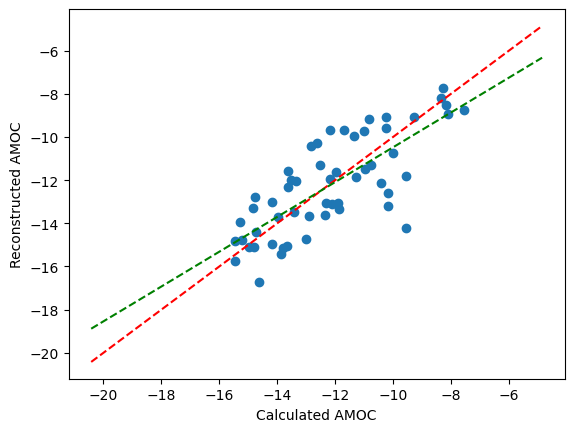

In [458]:
import matplotlib.pyplot as plt
plt.scatter(t_umo_obs.sel(time = test_predictions.time, method = "nearest").dv_dz_times_X.values, test_predictions.values)
# plt.scatter(t_umo_obs.sel(time = transport.time, method = "nearest").dv_dz_times_X.values, t_merged_argo_2000.sel(time = transport.time, method = 'nearest').values)
plt.xlabel('Calculated AMOC')
plt.ylabel('Reconstructed AMOC')
min_transport = min(test_predictions.min(), t_umo_obs.dv_dz_times_X.min()).values[()]
max_transport = max(test_predictions.max(), t_umo_obs.dv_dz_times_X.max()).values[()]
plt.plot([min_transport, max_transport], [min_transport, max_transport], 'r--')

from sklearn.linear_model import LinearRegression

lr = LinearRegression().fit(t_umo_obs.sel(time = test_predictions.time, method = "nearest").dv_dz_times_X.values.reshape(-1, 1), test_predictions.values.reshape(-1, 1))
# in_X = np.linspace(-35, -5, 100).reshape(-1, 1)
# plt.plot(in_X, lr.predict(in_X), 'k--')
# lr = LinearRegression().fit(t_umo_obs.sel(time = transport.time, method = "nearest").dv_dz_times_X.values.reshape(-1, 1), t_merged_argo_2000.sel(time = transport.time, method = 'nearest').values.reshape(-1, 1))
in_X = np.linspace(min_transport, max_transport, 100).reshape(-1, 1)
plt.plot(in_X, lr.predict(in_X), 'g--')

plt.savefig('../rapid-geostrophic-reconstruction/AMOC_reconstruction.png')

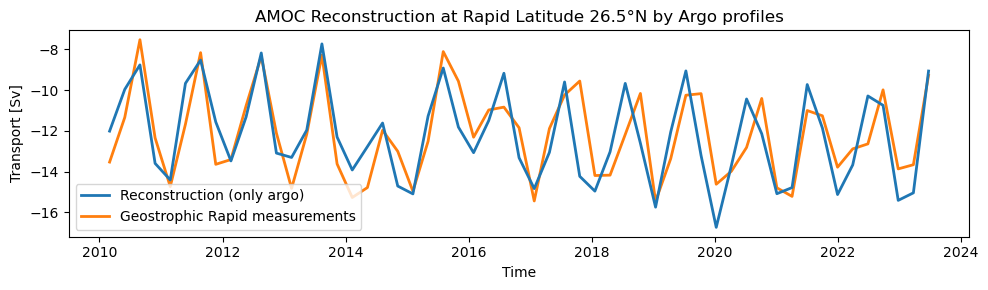

In [459]:
fig = plt.figure(figsize=(10, 3))
ax = fig.add_subplot(1,1,1)

# calc = t_merged_argo_2000.sel(time = transport.time, method = 'nearest')
# ax.plot(calc.time, calc.values, label = 'Geostrohphic calculation from Argos', alpha = .5, color = 'black')
rapid = t_umo_obs.sel(time = test_predictions.time, method = 'nearest')
ax.plot(test_predictions.time, test_predictions.values, label = 'Reconstruction (only argo)', linewidth = 2, zorder = 20)
ax.plot(rapid.time, rapid.dv_dz_times_X.values, label = 'Geostrophic Rapid measurements', linewidth = 2)

plt.legend()
ax.set_ylabel('Transport [Sv]')
ax.set_xlabel('Time')
plt.title('AMOC Reconstruction at Rapid Latitude 26.5°N by Argo profiles')
fig.tight_layout()
plt.savefig('../rapid-geostrophic-reconstruction/argo_nn_reconstruction.png')

In [112]:
ds_argo_merged_10days.sel(time = test_predictions.time, method = 'nearest').profile_mask.isel(z = 0).sum('pos')

InvalidIndexError: Reindexing only valid with uniquely valued Index objects

In [187]:
 np.median(np.abs(t_umo_obs.sel(time = test_predictions.time, method = 'nearest') - test_predictions).dv_dz_times_X.values)

1.741388181751649

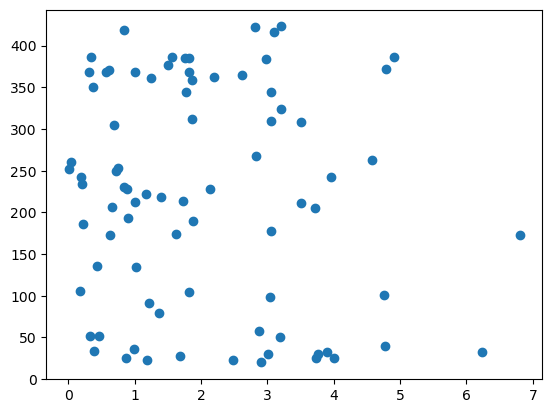

In [188]:
fig = plt.figure()
ax = fig.add_subplot(1,1,1)


ax.scatter(
    np.abs(t_umo_obs.sel(time = val_predictionq.time, method = 'nearest') - val_predictionq).dv_dz_times_X.values,
    ds_argo_merged_10days.sel(time = val_predictionq.time, method = 'nearest').profile_mask.isel(z = 0).sum('pos').values,
)

In [189]:
(
    train_dataset.y.rename('Train').hvplot.kde()
    * val_dataset.y.rename('Validation').hvplot.kde()
    * test_dataset.y.rename('Test').hvplot.kde()
)

:Overlay
   .NdOverlay.I   :NdOverlay   [Variable]
      :Distribution   [value]   (Density)
   .NdOverlay.II  :NdOverlay   [Variable]
      :Distribution   [value]   (Density)
   .NdOverlay.III :NdOverlay   [Variable]
      :Distribution   [value]   (Density)

### Find the minimum 

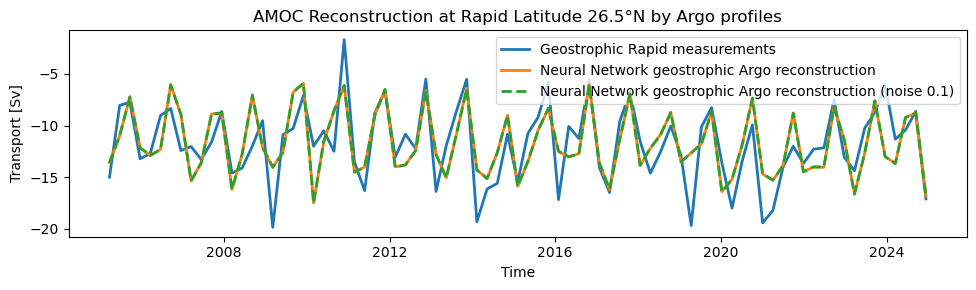

In [190]:
# wiggle the input
noise_scale = .1
noise_test_predictions, _ = make_predictions(test_dataset, best_model, test_indices, noise = noise_scale)

fig = plt.figure(figsize=(10, 3))
ax = fig.add_subplot(1,1,1)

# calc = t_merged_argo_2000.sel(time = transport.time, method = 'nearest')
# ax.plot(calc.time, calc.values, label = 'Geostrohphic calculation from Argos', alpha = .5, color = 'black')
rapid = t_umo_obs.sel(time = test_predictions.time, method = 'nearest')
ax.plot(rapid.time, rapid.dv_dz_times_X.values, label = 'Geostrophic Rapid measurements', linewidth = 2)
ax.plot(test_predictions.time, test_predictions.values, label = 'Neural Network geostrophic Argo reconstruction', linewidth = 2, zorder = 20)
ax.plot(noise_test_predictions.time, noise_test_predictions.values, label = f'Neural Network geostrophic Argo reconstruction (noise {noise_scale})', linewidth = 2, zorder = 20, linestyle = '--')

plt.legend()
ax.set_ylabel('Transport [Sv]')
ax.set_xlabel('Time')
plt.title('AMOC Reconstruction at Rapid Latitude 26.5°N by Argo profiles')
fig.tight_layout()
plt.savefig('argo_nn_reconstruction.png')

In [191]:
# Find the variance of the 46 dimensional hidden vector.

bottom_mask = test_predictions < -20

print('Bottom layer count ', bottom_mask.sum().values[()], 'out of ', len(test_predictions))


bottom_hidden = test_hidden_spaces[bottom_mask]
bottom_hidden_variance = bottom_hidden.var(axis = 0)


rest_hidden = test_hidden_spaces[~bottom_mask]
rest_hidden_variance = rest_hidden.var(axis = 0)

fig = plt.figure()
ax = fig.add_subplot(1,1,1)


ax.plot(bottom_hidden_variance, np.arange(242))
ax.plot(rest_hidden_variance, np.arange(242) )


Bottom layer count  0 out of  81


TypeError: list indices must be integers or slices, not DataArray

In [192]:
# Look in internal compartment embedding


from sklearn.manifold import TSNE


tsne = TSNE(n_components=2, random_state=42)

embedded = tsne.fit_transform(test_hidden_spaces)

fig = plt.figure()
ax = fig.add_subplot(1,1,1)

# embed = ax.scatter(embedded[:,0], embedded[:,1], c = test_predictions.values)
embed = ax.scatter(embedded[:,0], embedded[:,1], c = test_dataset.y)
ax.scatter(embedded[bottom_mask, 0], embedded[bottom_mask, 1], c = 'r')

plt.colorbar(embed)

AttributeError: 'list' object has no attribute 'shape'





#### From top to bottom 
-   20meter R2 0.37%; MAE 2.19; MSE 7.55
-  100meter R2 0.38%; MAE 2.21; MSE 7.47
-  200meter R2 0.46%; MAE 2.00; MSE 6.47
-  400meter R2 0.22%; MAE 2.40; MSE 9.42
-  500meter R2 0.20%; MAE 2.53; MSE 9.68
-  750meter R2 0.38%; MAE 2.15; MSE 7.47
- 1000meter R2 0.37%; MAE 2.15; MSE 7.52
- 1500meter R2 0.28%; MAE 2.38; MSE 8.65
- 2000meter R2 0.54%; MAE 1.77; MSE 5.48


#### From bottom to top
-   20meter R2 0.28%; MAE 2.31; MSE 8.67
-  200meter R2 0.27%; MAE 2.34; MSE 8.82
-  500meter R2 0.20%; MAE 2.49; MSE 9.66
- 1000meter R2 0.21%; MAE 2.48; MSE 9.56
- 1500meter R2 0.18%; MAE 2.57; MSE 9.87


#### Inbetween 
- 0-20 and 1500-2000 R2 0.48%; MAE 1.92; MSE 6.25
- 0-100 and 1500-200 R2 0.55%; MAE 1.86; MSE 5.36


### Transfer this to a RPAID dataset 

In [211]:
torch.save(best_model.cpu().state_dict(), '../rapid-geostrophic-reconstruction/data/11_viking_gesotrophic_prediction_multiple_cycles.pt')

## Compare embeddings 

In [139]:
ds_argo_merged_10days_std = ds_argo_merged_10days_std.sortby('z')
ds_argo_merged_10days_std

<xarray.Dataset>
Dimensions:       (time: 488, pos: 691, z: 29)
Coordinates:
  * pos           (pos) int64 0 1 2 3 4 5 6 7 ... 684 685 686 687 688 689 690
  * time          (time) datetime64[ns] 1970-01-01 1970-04-01 ... 2089-10-03
  * z             (z) float32 -1.85e+03 -1.655e+03 -1.471e+03 ... -9.454 -3.047
    lon           (time, pos) float32 -26.8 -40.85 -39.25 -18.0 ... nan nan nan
    lat           (time, pos) float32 28.02 26.64 27.53 29.33 ... nan nan nan
    time_1d       (time, pos) datetime64[ns] 1969-11-17T12:00:00 ... NaT
    pressure      (z) float32 1.85e+03 1.655e+03 1.471e+03 ... 16.36 9.454 3.047
Data variables:
    temperature   (time, pos, z) float64 1.932 2.114 2.027 1.874 ... 0.0 0.0 0.0
    salinity      (time, pos, z) float64 2.251 2.288 2.166 1.889 ... 0.0 0.0 0.0
    profile_mask  (time, pos, z) float64 1.0 1.0 1.0 1.0 1.0 ... 0.0 0.0 0.0 0.0
    ct            (time, pos, z) float64 4.44 5.025 5.615 6.105 ... 0.0 0.0 0.0
    rho           (time, pos, z) float64 0.05349 -0.1036 -0.3724 ... 0.0 0.0 0.0

In [140]:
stacked = ds_argo_merged_10days_std.stack(profile = ['time', 'pos'])
stacked = stacked.where(stacked.profile_mask.any('z'), drop = True)

# stacked_train = ds_argo_merged_10days_std.isel(time = train_indices).stack(profile = ['time', 'pos'])
# stacked_train = stacked_train.where(stacked_train.profile_mask.any('z'), drop = True)

# stacked_test = ds_argo_merged_10days_std.isel(time = test_indices).stack(profile = ['time', 'pos'])
# stacked_test = stacked_test.where(stacked_test.profile_mask.any('z'), drop = True)

In [147]:
ds_argo_merged

<xarray.Dataset>
Dimensions:       (pos: 691, z: 46, time: 488)
Coordinates:
  * pos           (pos) int64 0 1 2 3 4 5 6 7 ... 684 685 686 687 688 689 690
  * z             (z) float32 -3.047 -9.454 -16.36 ... -5.625e+03 -5.875e+03
  * time          (time) datetime64[ns] 1970-01-01 1970-04-01 ... 2089-10-03
    pressure      (z) float32 3.047 9.454 16.36 ... 5.625e+03 5.875e+03
    lon           (time, pos) float32 -26.8 -40.85 -39.25 -18.0 ... nan nan nan
    lat           (time, pos) float32 28.02 26.64 27.53 29.33 ... nan nan nan
    time_1d       (time, pos) datetime64[ns] 1969-11-17T12:00:00 ... NaT
Data variables:
    temperature   (time, pos, z) float32 24.23 24.21 24.21 24.2 ... nan nan nan
    salinity      (time, pos, z) float32 37.34 37.34 37.34 37.34 ... nan nan nan
    profile_mask  (time, pos) float64 1.0 1.0 1.0 1.0 1.0 ... 0.0 0.0 0.0 0.0
    ct            (time, pos, z) float64 24.15 24.13 24.13 24.12 ... nan nan nan
    rho           (time, pos, z) float64 1.025e+03 1.025e+03 ... nan nan

In [149]:
## Copied code from 06

def load_merged_argo_dataset_and_tumo_argo(time_smoothing, lat_bounds = None):
    ds_argo_merged = xr.open_dataset(f'../rapid-geostrophic-reconstruction/data/ds_argo_{time_smoothing}.nc')
    t_umo_obs = xr.open_dataset(f'../rapid-geostrophic-reconstruction/data/t_umo_obs_2000ref.nc')

    t_umo_obs = t_umo_obs.resample(time = time_smoothing).mean()

    ds_argo_merged = ds_argo_merged.sel(time = t_umo_obs.time.data)#, method = 'nearest')
    ds_argo_merged = ds_argo_merged.isel(z = slice(None, None, -1))

    if lat_bounds is not None:
        ds_argo_merged = ds_argo_merged.where((ds_argo_merged.lat >= lat_bounds[0]) & (ds_argo_merged.lat <= lat_bounds[1]))

    return ds_argo_merged, t_umo_obs


def create_argo_set():
    ds_argo_merged_10days, t_umo_10days = load_merged_argo_dataset_and_tumo_argo(time_smoothing, lat_bounds = lat_bounds)

    compartments = [
        ['west_p', -76.74, -70, 'west'],
        ['mar_west_p', -60, -47, 'east'],
        ['mar_east_p', -47, -40, 'west'],
        ['east_p', -30, -13.5, 'east']
    ]

    ds_argo_merged_sim = xr.open_dataset(f'../rapid-geostrophic-reconstruction/data/ds_argo_{time_smoothing}_viking.nc')
    depth_boundaries = np.diff(ds_argo_merged_sim.z.values)
    depth_boundaries = (depth_boundaries / 2) + ds_argo_merged_sim.z.values[:-1]

    grouped_depth_profile = ds_argo_merged_10days.groupby_bins('z', np.concatenate([depth_boundaries, [0.0]])).mean()
    ds_argo_merged_10days = grouped_depth_profile.assign_coords(z_bins = ds_argo_merged_sim.z.values[1:]).rename({'z_bins': 'z'}).interpolate_na('z')

    ds_argo_merged_10days = ds_argo_merged_10days.transpose('time', 'z', 'pos')


    # We only take the first 2000 meters depth
    ds_argo_merged_10days = ds_argo_merged_10days.where(ds_argo_merged_10days.z > -2000, drop = True)

    ds_argo_merged_10days = ds_argo_merged_10days.where(ds_argo_merged_10days.salinity > 0)#.fillna(0)

    ds_argo_merged_10days = ds_argo_merged_10days.sortby('z')
    # ds_argo_merged_10days, t_umo_10days = load_merged_argo_dataset_and_tumo_argo(time_smoothing, lat_bounds = lat_bounds)

    # compartments = [
    #     ['west_p', -76.74, -70, 'west'],
    #     ['mar_west_p', -60, -47, 'east'],
    #     ['mar_east_p', -47, -40, 'west'],
    #     ['east_p', -30, -13.5, 'east']
    # ]

    # # ds_argo_merged_sim = xr.open_dataset(f'../rapid-geostrophic-reconstruction/data/ds_argo_{time_smoothing}_viking.nc')

    # suffixe = ['_70None', '_2nd_NoneNone']
    # ds_argo_merged_sim, t_umo_obs, t_delta = load_merged_argo_dataset_and_tumo_cycles(suffixe, time_smoothing)

    


    # depth_boundaries = np.diff(ds_argo_merged_sim.z.values)
    # depth_boundaries = (depth_boundaries / 2) + ds_argo_merged_sim.z.values[:-1]
    # print(ds_argo_merged_10days.z)
    # grouped_depth_profile = ds_argo_merged_10days.groupby_bins('z', np.concatenate([np.sort(depth_boundaries), [0.0]])).mean()
    # ds_argo_merged_10days = grouped_depth_profile.assign_coords(z_bins = ds_argo_merged_sim.z.values[1:]).rename({'z_bins': 'z'}).interpolate_na('z')

    # ds_argo_merged_10days = ds_argo_merged_10days.transpose('time', 'z', 'pos')


    # # We only take the first 2000 meters depth
    # ds_argo_merged_10days = ds_argo_merged_10days.where(ds_argo_merged_10days.z > -2000, drop = True)

    # ds_argo_merged_10days = ds_argo_merged_10days.where(ds_argo_merged_10days.salinity > 0)

    return ds_argo_merged_10days

ds_argo_merged_10days_argo = create_argo_set()

rho_mean = ds_argo_merged_10days_argo.where(ds_argo_merged_10days_argo.profile_mask).mean(['time', 'pos']).rho

ds_argo_merged_10days_std_argo = standardize_rho(
    ds_argo_merged_10days_argo,
    rho_mean=rho_mean, 
    rho_std=rho_std,
)

ds_argo_merged_10days_std_argo = ds_argo_merged_10days_std_argo.fillna(0)

# ds_argo_merged_10days_std_argo = standardize_temperature(
#     ds_argo_merged_10days_std_argo,
#     temperature_mean=temperature_mean,
#     temperature_std=temperature_std,
# )

# ds_argo_merged_10days_std_argo = standardize_salinity(
#     ds_argo_merged_10days_std_argo,
#     salinity_mean=salinity_mean,
#     salinity_std=salinity_std,
# )


ds_argo_merged_10days_std_argo = ds_argo_merged_10days_std_argo.sortby('z')
stacked_argo = ds_argo_merged_10days_std_argo.stack(profile = ['time', 'pos'])
stacked_argo = stacked_argo.where(stacked_argo.profile_mask.any('z'), drop = True)


/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(


In [53]:
from sklearn.manifold import TSNE




In [299]:
sample_per_batch = 7_000

# select a random sample of profiles 

sample_indices = np.random.choice(np.arange(len(stacked.profile)), sample_per_batch, replace = False)
# sample_indices_train = np.random.choice(np.arange(len(stacked_train.profile)), sample_per_batch, replace = False)
# sample_indices_test = np.random.choice(np.arange(len(stacked_test.profile)), sample_per_batch, replace = False)
sample_indices_argo = np.random.choice(np.arange(len(stacked_argo.profile)), sample_per_batch, replace = False)

variable = 'rho'

X_viking_source = stacked.isel(profile = sample_indices).drop_vars('profile')
X_sample = np.concatenate(
    [
        X_viking_source[variable].values.T,
        # X_viking_source['temperature'].values.T,
        # X_viking_source['salinity'].values.T,
    ], axis = -1
)
# X_sample_train = stacked_train.isel(profile = sample_indices_train).drop_vars('profile')[variable].values.T
# X_sample_test = stacked_test.isel(profile = sample_indices_test).drop_vars('profile')[variable].values.T
X_argo_source = stacked_argo.isel(profile = sample_indices_argo).drop_vars('profile')
X_argo = np.concatenate(
    [
        X_argo_source[variable].values.T,
        # X_argo_source['temperature'].values.T,
        # X_argo_source['salinity'].values.T,
    ], axis = -1
)   


/scratch/SlurmTMP/smomw507.13496247/ipykernel_2176255/3481578201.py:12: DeprecationWarning: Deleting a single level of a MultiIndex is deprecated. Previously, this deleted all levels of a MultiIndex. Please also drop the following variables: {'pos', 'time'} to avoid an error in the future.
  X_viking_source = stacked.isel(profile = sample_indices).drop_vars('profile')
/scratch/SlurmTMP/smomw507.13496247/ipykernel_2176255/3481578201.py:22: DeprecationWarning: Deleting a single level of a MultiIndex is deprecated. Previously, this deleted all levels of a MultiIndex. Please also drop the following variables: {'pos', 'time'} to avoid an error in the future.
  X_argo_source = stacked_argo.isel(profile = sample_indices_argo).drop_vars('profile')


In [300]:
X_sample.shape, X_argo.shape

((7000, 29), (7000, 29))

In [301]:
dataset = np.concatenate([X_sample, X_argo], axis = 0)
labels = np.concatenate(
    [np.ones(X_sample.shape[0]) * 0,
    np.ones(X_argo.shape[0]) * 1]
)


In [302]:
labels.shape

(14000,)

In [303]:
from sklearn.manifold import TSNE
mapped_points = TSNE(n_components=2, perplexity=30, n_iter=3000).fit_transform(dataset)

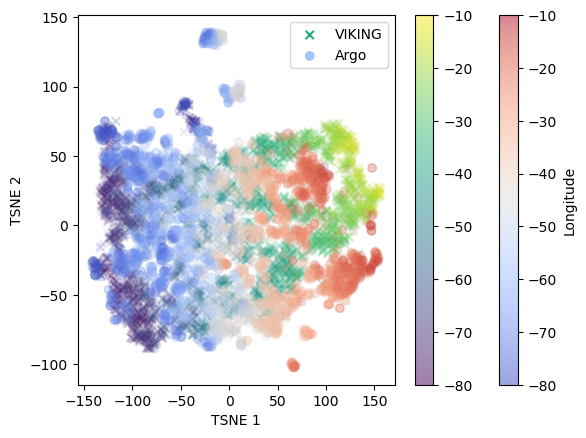

In [304]:
fig = plt.figure()
ax = fig.add_subplot(1,1,1)
alpha = .0825464
v_scatter = ax.scatter(mapped_points[:sample_per_batch, 0], mapped_points[:sample_per_batch,1], alpha = alpha, label = 'VIKING', c = stacked.isel(profile = sample_indices).lon.values, marker = 'x', vmin = -80, vmax = -10)
a_scatter = ax.scatter(mapped_points[sample_per_batch:, 0], mapped_points[sample_per_batch:,1], alpha = alpha, label = 'Argo', c= stacked_argo.isel(profile = sample_indices_argo).lon.values, marker = 'o', vmin = -80, vmax = -10, cmap='coolwarm')

# make a colorbar that is not tranpsarent for the argo scatter plot
cb = plt.colorbar(a_scatter, ax = ax,label = 'Longitude')
cb.solids.set_alpha(.5)

cb = fig.colorbar(v_scatter, ax = ax)
cb.solids.set_alpha(.5)

ax.set_xlabel('TSNE 1')
ax.set_ylabel('TSNE 2')


legend = plt.legend()
for lh in legend.legend_handles:
    lh.set_alpha(1)

In [73]:
fig.savefig('../rapid-geostrophic-reconstruction/argo_viking_tsne_rho.png', dpi = 300)

ValueError: x and y must have same first dimension, but have shapes (87,) and (29,)

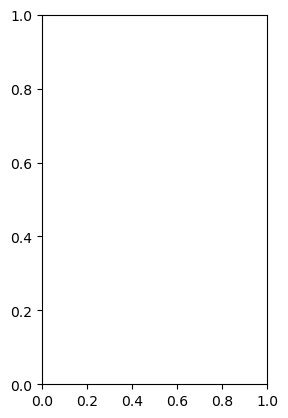

In [173]:
fig = plt.figure()
ax = fig.add_subplot(1,2,1)
ax.plot( X_sample.mean(axis = 0), ds_argo_merged_10days_std.z)
ax.plot( X_argo.mean(axis = 0), ds_argo_merged_10days_std.z)


ax = fig.add_subplot(1,2,2)
ax.plot( X_sample.std(axis = 0), ds_argo_merged_10days_std.z)
ax.plot( X_argo.std(axis = 0), ds_argo_merged_10days_std.z)


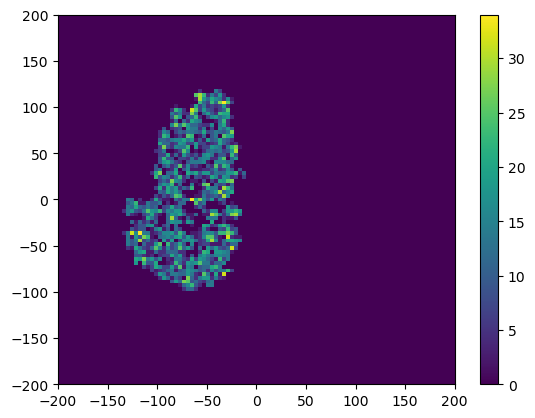

In [249]:
fig = plt.figure()
ax = fig.add_subplot(1,1,1)
bound = 200

a, _, _, h2d = ax.hist2d(mapped_points[5000:, 0], mapped_points[5000:,1], bins = np.linspace(-bound, bound, 100), cmap = 'viridis')
b, _, _, _ = ax.hist2d(mapped_points[:5000, 0], mapped_points[:5000,1], bins = np.linspace(-bound, bound, 100), cmap = 'viridis')
fig.colorbar(h2d, ax = ax)

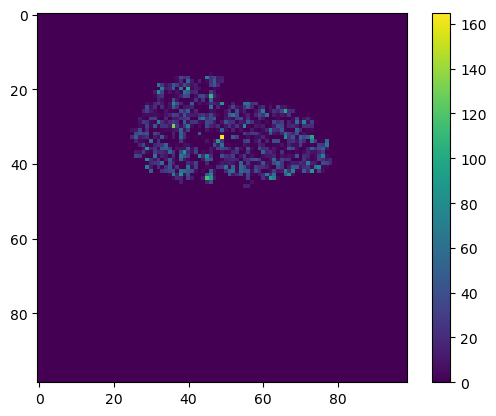

In [250]:
i = plt.imshow(a * b)
plt.colorbar(i)

In [251]:
dataset.shape

(16000, 29)

In [305]:
import torch.utils

data_tensor = torch.Tensor(dataset)
labels_tensor = torch.Tensor(labels).reshape(-1, 1)




In [306]:
data_tensor.shape

torch.Size([14000, 29])

In [307]:
indices = np.arange(len(dataset))
np.random.shuffle(indices)

train_indices = indices[:int(len(dataset) * .8)]
val_indices = indices[int(len(dataset) * .8):int(len(dataset) * .9)]
test_indices = indices[int(len(dataset) * .9):]


mean = data_tensor[train_indices].mean(axis = 0)
std = data_tensor[train_indices].std(axis = 0)

data_tensor = (data_tensor - mean) / std

train_dataset = torch.utils.data.TensorDataset(data_tensor[train_indices], labels_tensor[train_indices])
val_dataset = torch.utils.data.TensorDataset(data_tensor[val_indices], labels_tensor[val_indices])
test_dataset = torch.utils.data.TensorDataset(data_tensor[test_indices], labels_tensor[test_indices])


train_dl = DataLoader(train_dataset, batch_size = 32, shuffle = True)
val_dl = DataLoader(val_dataset, batch_size = 32, shuffle = False)
test_dl = DataLoader(test_dataset, batch_size = 32, shuffle = False)


In [308]:
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score

lr = SVC().fit(dataset[train_indices], labels[train_indices])


prediction =lr.predict(dataset[test_indices])


print(confusion_matrix(labels[test_indices], prediction), f1_score(labels[test_indices], prediction), accuracy_score(labels[test_indices], prediction))

[[668  46]
 [ 26 660]] 0.9482758620689655 0.9485714285714286


In [309]:
from torch.autograd import Function

class GradReverse(Function):
    @staticmethod
    def forward(ctx, x):
        return x.view_as(x)

    @staticmethod
    def backward(ctx, grad_output):
        return (grad_output * -1)

# def grad_reverse(x):
#     return GradReverse.apply(x)


class Profile_Encoder(nn.Module):
    
        def __init__(self, hidden, input_dim):
            super(Profile_Encoder, self).__init__()
            self.hidden = hidden
            self.fc1 = nn.Linear(input_dim, self.hidden)
            self.fc2 = nn.Linear(self.hidden, self.hidden)
            self.fc3 = nn.Linear(self.hidden, self.hidden)
    
        def forward(self, x):
            x = torch.relu(self.fc1(x))
            x = torch.relu(self.fc2(x))
            x = torch.relu(self.fc3(x))
            return x

class Model(nn.Module):

    def __init__(self, hidden, input_dim):
        super(Model, self).__init__()
        self.hidden = hidden
        self.fc1 = nn.Linear(input_dim, self.hidden)
        self.fc2 = nn.Linear(self.hidden, self.hidden)

        self.encoder = Profile_Encoder(self.hidden, input_dim)
        
        self.domain_fc1 = nn.Linear(self.hidden, self.hidden)
        self.domain_fc2 = nn.Linear(self.hidden, self.hidden)
        self.domain_fc3 = nn.Linear(self.hidden, 1)
        self.decoder_fc1 = nn.Linear(self.hidden, self.hidden)
        self.decoder_fc3 = nn.Linear(self.hidden, input_dim)
        self.grad_reverse = GradReverse.apply

    def forward(self, x):
        x = self.encoder(x)

        domain = self.grad_reverse(x)
        domain = torch.relu(self.domain_fc1(domain))
        # domain = torch.relu(self.domain_fc2(domain))
        domain = torch.sigmoid(self.domain_fc3(domain))
        decoder = torch.relu(self.decoder_fc1(x))
        decoder = self.decoder_fc3(decoder)
        return decoder, domain
    

       

In [347]:
 
hidden_dim = 16
model = Model(hidden_dim, 29)

criterion_mse = nn.MSELoss()
criterion_bce = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr = .001)
num_epochs = 100
lr_scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)


def cacl_loss(output_recons, output_domain, target, domain):
    return 1*criterion_mse(output_recons, target) + 10 * criterion_bce(output_domain, domain)

best_val_loss = 1e10
best_epoch = 0
for epoch in range(num_epochs):

    model.train()
    for i, (data, domain) in enumerate(train_dl):
        optimizer.zero_grad()
        output = model(data)
        loss = cacl_loss(*output, data, domain)
        loss.backward()
        optimizer.step()

    model.eval()
    total_val_loss = 0.
    for i, (data, domain) in enumerate(val_dl):
        output = model(data)
        loss = cacl_loss(*output, data, domain)
        total_val_loss += loss.item()
    total_val_loss /= len(val_dl)

    if total_val_loss < best_val_loss:
        best_val_loss = total_val_loss
        best_epoch = epoch
        best_model = deepcopy(model)
        print('New best model found in epoch: ', epoch, 'with val loss: ', total_val_loss)


    lr_scheduler.step()
    print(f'Epoch {epoch}, Loss: {loss.item()}, Val loss: {total_val_loss}')

    if epoch - best_epoch > 20: 
        break

model = best_model

New best model found in epoch:  0 with val loss:  7.372273661873558
Epoch 0, Loss: 7.709283828735352, Val loss: 7.372273661873558
New best model found in epoch:  1 with val loss:  7.13316780870611
Epoch 1, Loss: 6.878652572631836, Val loss: 7.13316780870611
Epoch 2, Loss: 7.04205322265625, Val loss: 7.186543291265314
Epoch 3, Loss: 6.878937721252441, Val loss: 7.144357204437256
Epoch 4, Loss: 7.068800449371338, Val loss: 7.148245930671692
Epoch 5, Loss: 7.241899013519287, Val loss: 7.175326119769704
New best model found in epoch:  6 with val loss:  7.130736361850392
Epoch 6, Loss: 7.115325450897217, Val loss: 7.130736361850392
New best model found in epoch:  7 with val loss:  7.10778458551927
Epoch 7, Loss: 7.058689117431641, Val loss: 7.10778458551927
Epoch 8, Loss: 7.166833877563477, Val loss: 7.180204629898071
Epoch 9, Loss: 7.111661911010742, Val loss: 7.12739342992956
New best model found in epoch:  10 with val loss:  7.0918979753147475
Epoch 10, Loss: 7.068519115447998, Val loss:

In [348]:
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix

In [349]:
gt_domain = []
pred_domain = []

gt_recons = []
pred_recons = []

for i, (data, domain) in enumerate(test_dl):
    output = model(data)
    loss = cacl_loss(*output, data, domain)

    # calculate the F1 score
    gt_domain.append(domain.detach().numpy())
    pred_domain.append(output[1].detach().numpy())

    gt_recons.append(data.detach().numpy())
    pred_recons.append(output[0].detach().numpy())




gt_domain = np.concatenate(gt_domain)
pred_domain = np.concatenate(pred_domain)

gt_recons = np.concatenate(gt_recons)
pred_recons = np.concatenate(pred_recons)

gt_domain = gt_domain >.5
pred_domain = pred_domain > .5

print(f'F1 score: {f1_score(gt_domain, pred_domain):.4f}; Accuracy: {accuracy_score(gt_domain, pred_domain)*100:.2f}%', confusion_matrix(gt_domain, pred_domain))

F1 score: 0.5981; Accuracy: 52.86% [[249 465]
 [195 491]]


In [350]:
(np.concatenate([gt_domain, pred_domain], axis = -1).sum(axis = -1) == 0).sum()

249

In [351]:
((gt_recons - pred_recons)**2).mean(axis = 0),((gt_recons - pred_recons)**2).mean() 

(array([0.0233143 , 0.02068377, 0.02544951, 0.06630912, 0.21232666,
        0.16467246, 0.10527717, 0.0438609 , 0.03556895, 0.03261021,
        0.03205992, 0.02644051, 0.02005361, 0.01862576, 0.02134647,
        0.02217865, 0.0232618 , 0.0279077 , 0.03135695, 0.03245516,
        0.03066411, 0.02269321, 0.01807611, 0.02120112, 0.01645064,
        0.00581315, 0.00955634, 0.01087442, 0.01683972], dtype=float32),
 0.039238926)

In [343]:
assert ((gt_recons - pred_recons)**2).mean() < .1

AssertionError: 

In [352]:
embedded_profiles = model.encoder(data_tensor).detach().numpy()
embedded_profiles.shape

(14000, 16)

In [335]:
from sklearn.manifold import TSNE
mapped_points = TSNE(n_components=2, perplexity=30, n_iter=3000).fit_transform(embedded_profiles)

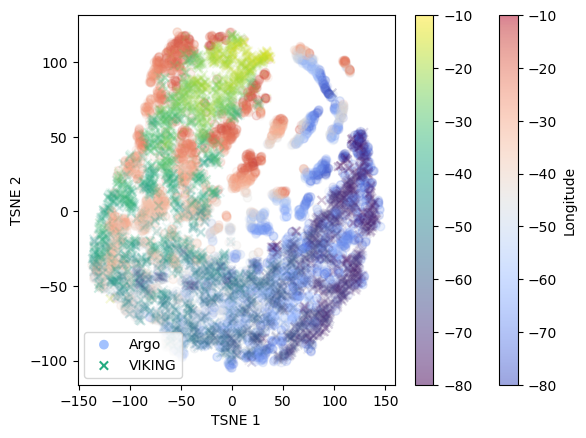

In [336]:
fig = plt.figure()
ax = fig.add_subplot(1,1,1)
alpha = .0825464
a_scatter = ax.scatter(mapped_points[sample_per_batch:, 0], mapped_points[sample_per_batch:,1], alpha = alpha, label = 'Argo', c= stacked_argo.isel(profile = sample_indices_argo).lon.values, marker = 'o', vmin = -80, vmax = -10, cmap='coolwarm')
v_scatter = ax.scatter(mapped_points[:sample_per_batch, 0], mapped_points[:sample_per_batch,1], alpha = alpha, label = 'VIKING', c = stacked.isel(profile = sample_indices).lon.values, marker = 'x', vmin = -80, vmax = -10)

# make a colorbar that is not tranpsarent for the argo scatter plot
cb = plt.colorbar(a_scatter, ax = ax,label = 'Longitude')
cb.solids.set_alpha(.5)

cb = fig.colorbar(v_scatter, ax = ax)
cb.solids.set_alpha(.5)

ax.set_xlabel('TSNE 1')
ax.set_ylabel('TSNE 2')


legend = plt.legend()
for lh in legend.legend_handles:
    lh.set_alpha(1)

In [353]:
from sklearn.svm import SVC

lr = SVC().fit(embedded_profiles[train_indices], labels[train_indices])

prediction =lr.predict(embedded_profiles[test_indices])


test_labels = labels[test_indices]
print(confusion_matrix(test_labels, prediction), f1_score(test_labels, prediction), accuracy_score(test_labels, prediction))

assert f1_score(test_labels, prediction) < .64

[[575 139]
 [267 419]] 0.6736334405144694 0.71


AssertionError: 

In [217]:
[b.shape for b in model.encoder.state_dict().values()]

[torch.Size([64, 87]),
 torch.Size([64]),
 torch.Size([64, 64]),
 torch.Size([64]),
 torch.Size([64, 64]),
 torch.Size([64])]

In [354]:
torch.save(model.encoder.state_dict(), f'../rapid-geostrophic-reconstruction/profile_encoder_{hidden_dim}dim.pt')